In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA OVERVIEW

# Credit Card Customer Dataset - Data Dictionary

> Dataset gốc: 8950 khách hàng, 18 cột, phản ánh hành vi sử dụng thẻ tín dụng trong 6 tháng gần nhất.

---

## Thông tin khách hàng

| Cột | Kiểu | Mô tả |
|-----|------|-------|
| **CUST_ID** | string | Mã định danh duy nhất (vd: C10001). **Không dùng trong phân tích**, chỉ dùng để nhận diện khách hàng. |

---

## Nhóm 1 — Số dư & Tần suất cập nhật

| Cột | Kiểu | Mô tả | Ví dụ thực tế |
|-----|------|-------|---------------|
| **BALANCE** | float | Số dư nợ còn lại trong tài khoản để mua hàng (số tiền chưa trả). Càng cao = nợ càng nhiều. | Số dư: $1,500 → khách đang nợ ngân hàng $1,500 chưa trả |
| **BALANCE_FREQUENCY** | float (0–1) | Tần suất cập nhật số dư. 1 = cập nhật mỗi kỳ, 0 = không cập nhật. | 0.9 → khách thanh toán gần như mỗi tháng; 0.2 → hiếm khi thanh toán |

---

## Nhóm 2 — Hành vi mua hàng

| Cột | Kiểu | Mô tả | Ví dụ thực tế |
|-----|------|-------|---------------|
| **PURCHASES** | float | Tổng **số tiền** đã mua (bao gồm cả trả góp và đứt). | Tổng mua: $5,000/tháng → Purchase activity cao |
| **ONEOFF_PURCHASES** | float | **Số tiền** mua lớn nhất trong **một lần** mua đứt (không trả góp). | Mua TV $2,000 đứt một lần → ONEOFF = $2,000 |
| **INSTALLMENTS_PURCHASES** | float | **Số tiền** mua theo hình thức **trả góp**. | Mua máy $1,200 chia 6 tháng → INSTALLMENTS = $1,200 |
| **PURCHASES_FREQUENCY** | float (0–1) | Tần suất mua hàng **tổng thể** (mọi hình thức). 1 = luôn luôn có giao dịch. | 0.9 → mua gần như mỗi tháng |
| **ONEOFF_PURCHASES_FREQUENCY** | float (0–1) | Tần suất mua **đứt** (không trả góp). 1 = chỉ mua đứt. | 1.0 → luôn mua đứt; 0.2 → hiếm khi mua đứt (thường trả góp) |
| **PURCHASES_INSTALLMENTS_FREQUENCY** | float (0–1) | Tần suất mua **trả góp**. 1 = luôn trả góp. | 0.8 → thường xuyên mua trả góp |
| **PURCHASES_TRX** | int | **Số lượng giao dịch mua** (đếm giao dịch, không phải số tiền). | 45 giao dịch → khách rất active |

> **Quan hệ quan trọng:**
> - `PURCHASES` = `ONEOFF_PURCHASES` + `INSTALLMENTS_PURCHASES`
> - `PURCHASES_FREQUENCY` ≥ `ONEOFF_PURCHASES_FREQUENCY` + `PURCHASES_INSTALLMENTS_FREQUENCY`

---

## Nhóm 3 — Rút tiền mặt (Cash Advance)

> Cash Advance = rút tiền mặt từ thẻ tín dụng. Phí cao, lãi suất cao hơn mua hàng. Thường là dấu hiệu cần tiền gấp.

| Cột | Kiểu | Mô tả | Ví dụ thực tế |
|-----|------|-------|---------------|
| **CASH_ADVANCE** | float | Tổng **số tiền** đã rút mặt từ thẻ. | Rút $3,000 → khách có thể đang gặp khó khăn tài chính |
| **CASH_ADVANCE_FREQUENCY** | float (0–1) | Tần suất rút tiền mặt. 1 = rút mỗi tháng. | 0.5 → rút tiền cách tháng |
| **CASH_ADVANCE_TRX** | int | **Số lượng giao dịch** rút tiền mặt. | 8 lần rút → thường xuyên rút tiền |

---

## Nhóm 4 — Thanh toán & Hạn mức

| Cột | Kiểu | Mô tả | Ví dụ thực tế |
|-----|------|-------|---------------|
| **CREDIT_LIMIT** | float | **Hạn mức** thẻ tín dụng tối đa. | Hạn mức: $10,000 → ngân hàng tin tưởng khách |
| **PAYMENTS** | float | Tổng **số tiền** đã thanh toán (trả nợ). | Trả $2,000/tháng → khách có trách nhiệm tài chính |
| **MINIMUM_PAYMENTS** | float | Số tiền **than toán tối thiểu** bắt buộc mỗi tháng (thường ~5% số dư). | Minimum payment: $50/tháng |
| **PRC_FULL_PAYMENT** | float (0–1) | Tỷ lệ **thanh toán đủ** (trả hết số dư). 1 = luôn trả hết nợ. | 0.1 → chỉ trả đủ 10% số dư; 0.9 → thường xuyên trả hết |
| **TENURE** | int | **Thời hạn** sử dụng thẻ (tháng). Hầu hết = 12 (mới nhất). | TENURE = 12 → khách dùng thẻ từ đầu (thường là khách mới) |



In [130]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [131]:
df = pd.read_csv('/content/drive/MyDrive/ML/CC GENERAL.csv')

In [132]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [133]:
df.shape

(8950, 18)

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [135]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Dataset Summary

### Thông tin chung
- **8,950 khách hàng**, 18 cột, hành vi trong 6 tháng
- Missing values: MINIMUM_PAYMENTS (313), CREDIT_LIMIT (1)

---

### Insight 1: Đa số khách nhỏ, ít hoạt động
| Metric | Mean | Median | Bottom 25% |
|--------|------|--------|-----------|
| PURCHASES | $1,003 | $361 | < $39 |
| PURCHASES_TRX | 14.7 lần | 7 lần | ≤ 1 lần |

- `PURCHASES_TRX 25% = 1` → **25% khách chỉ mua 1 lần** trong 6 tháng
- `TENURE TB = 11.5/12` → Hầu hết khách **dùng thẻ từ đầu**

---

### Insight 2: Phân hóa mạnh — thiểu số kéo trung bình lên
| | Mean | Median | Max |
|---|---|---|---|
| BALANCE | $1,564 | $873 | $19,043 |
| CREDIT_LIMIT | $4,494 | $3,000 | $30,000 |
| ONEOFF_PURCHASES | $592 | $38 | $40,761 |

- **Mean >> Median** ở mọi feature → Phân phối **lệch phải** (right-skewed)
- Max gấp 10-60 lần mean → Thiểu số "heavy user" kéo giá trị trung bình

---

### Insight 3: Rủi ro tài chính — rút tiền mặt & không trả nợ
| | Mean | Median |
|---|---|---|
| CASH_ADVANCE | $979 | **$0** |
| PRC_FULL_PAYMENT | 15.4% | **0** |

- **Median CASH_ADVANCE = 0** → **>50% khách không bao giờ rút tiền mặt**, nhưng nhóm nhỏ rút rất nhiều (max = $47,137)
- **Median PRC_FULL_PAYMENT = 0** → **>50% khách KHÔNG trả hết nợ**

---

### Insight 4: Trả góp phổ biến hơn mua đứt
| Frequency | Mean |
|-----------|------|
| INSTALLMENTS_FREQUENCY | **0.36** |
| ONEOFF_PURCHASES_FREQUENCY | **0.20** |
| PURCHASES_FREQUENCY | **0.49** |

- Khách mua ít hơn nửa thời gian, và **ưa trả góp hơn mua đứt**
- Nhưng ONEOFF_PURCHASES > INSTALLMENT_PURCHASES về tổng tiền ($592 vs $411) → Khi mua đứt, mua với số tiền lớn hơn

---

### Clustering
Các feature có phân phối (tách nhóm tốt):

1. **BALANCE** — Đại diện cho số dư nợ — phản ánh rủi ro tài chính
2. **PURCHASES** — 	Đại diện cho hành vi mua hàng
3. **CREDIT_LIMIT** — Đại diện cho hạn mức/thu nhập
4. **PURCHASES_FREQUENCY** — Đại diện cho khả năng thanh toán

DATA CLEANING

In [136]:
df.duplicated().sum()

np.int64(0)

In [137]:
set(df['TENURE'])

{6, 7, 8, 9, 10, 11, 12}

In [138]:
df = df.drop_duplicates()

## 2. Xử lý Duplicate (hàng trùng lặp)

Kiểm tra và loại bỏ các hàng trùng lặp hoàn toàn trong dataset.

**Tại sao cần loại bỏ?**
- Hàng trùng lặp làm **kéo lệch kết quả** clustering/classification
- Trùng lặp = khách hàng xuất hiện 2 lần → bị đếm 2 lần → phân phối méo

In [139]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


## 3. Xử lý Missing Values

### Nguyên nhân có giá trị thiếu

| Cột | Số missing | Nguyên nhân có thể |
|------|-----------|-------------------|
| **MINIMUM_PAYMENTS** | 313 | Khách **không có dư nợ** → không cần trả minimum. Khi BALANCE = 0, ngân hàng không tính minimum payment. |
| **CREDIT_LIMIT** | 1 | Khách **không có thẻ tín dụng** active hoặc là khách hàng mới chưa được gán hạn mức. |

### Cách xử lý
- **`fillna(df.mean())`** → Thay missing bằng **giá trị trung bình** của cột đó
- **Không xóa hàng** vì 313/8950 = ~3.5% missing → ảnh hưởng nhỏ, không đáng kể

In [140]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [141]:
df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [142]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [143]:
df.drop("CUST_ID", axis=1, inplace=True)

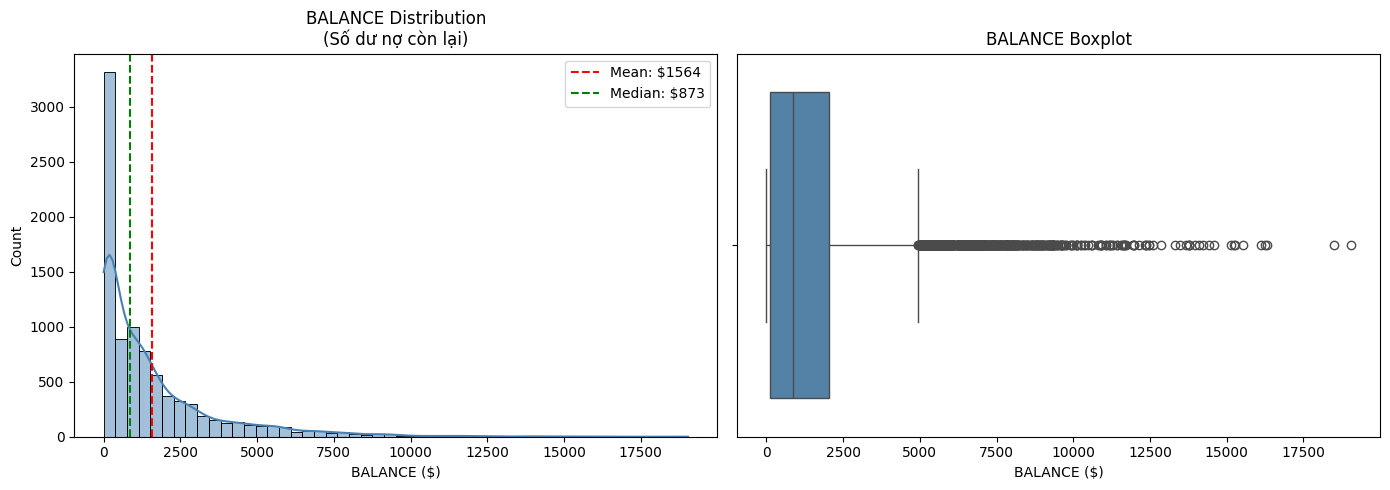

In [144]:
# =============================================
# Nhóm 1: Số dư (BALANCE)
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(df['BALANCE'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('BALANCE Distribution\n(Số dư nợ còn lại)', fontsize=12)
axes[0].set_xlabel('BALANCE ($)')
axes[0].axvline(df['BALANCE'].mean(), color='red', linestyle='--', label=f'Mean: ${df["BALANCE"].mean():.0f}')
axes[0].axvline(df['BALANCE'].median(), color='green', linestyle='--', label=f'Median: ${df["BALANCE"].median():.0f}')
axes[0].legend()

# Boxplot để thấy outliers
sns.boxplot(x=df['BALANCE'], ax=axes[1], color='steelblue')
axes[1].set_title('BALANCE Boxplot', fontsize=12)
axes[1].set_xlabel('BALANCE ($)')

plt.tight_layout()
plt.show()



### Nhóm 1 — Kết luận: Số dư (BALANCE)

| | Giá trị |
|---|---|
| Mean | $1,564 |
| Median | $873 |
| Max | $19,043 |
| Phân phối | **Lệch phải** (Mean >> Median) |

> → **Mean gấp ~2 lần Median** → Phân phối bị kéo bởi thiểu số khách có số dư rất cao
> → **Boxplot**: Rất nhiều outliers phía trên → Cần xử lý outliers trước khi clustering

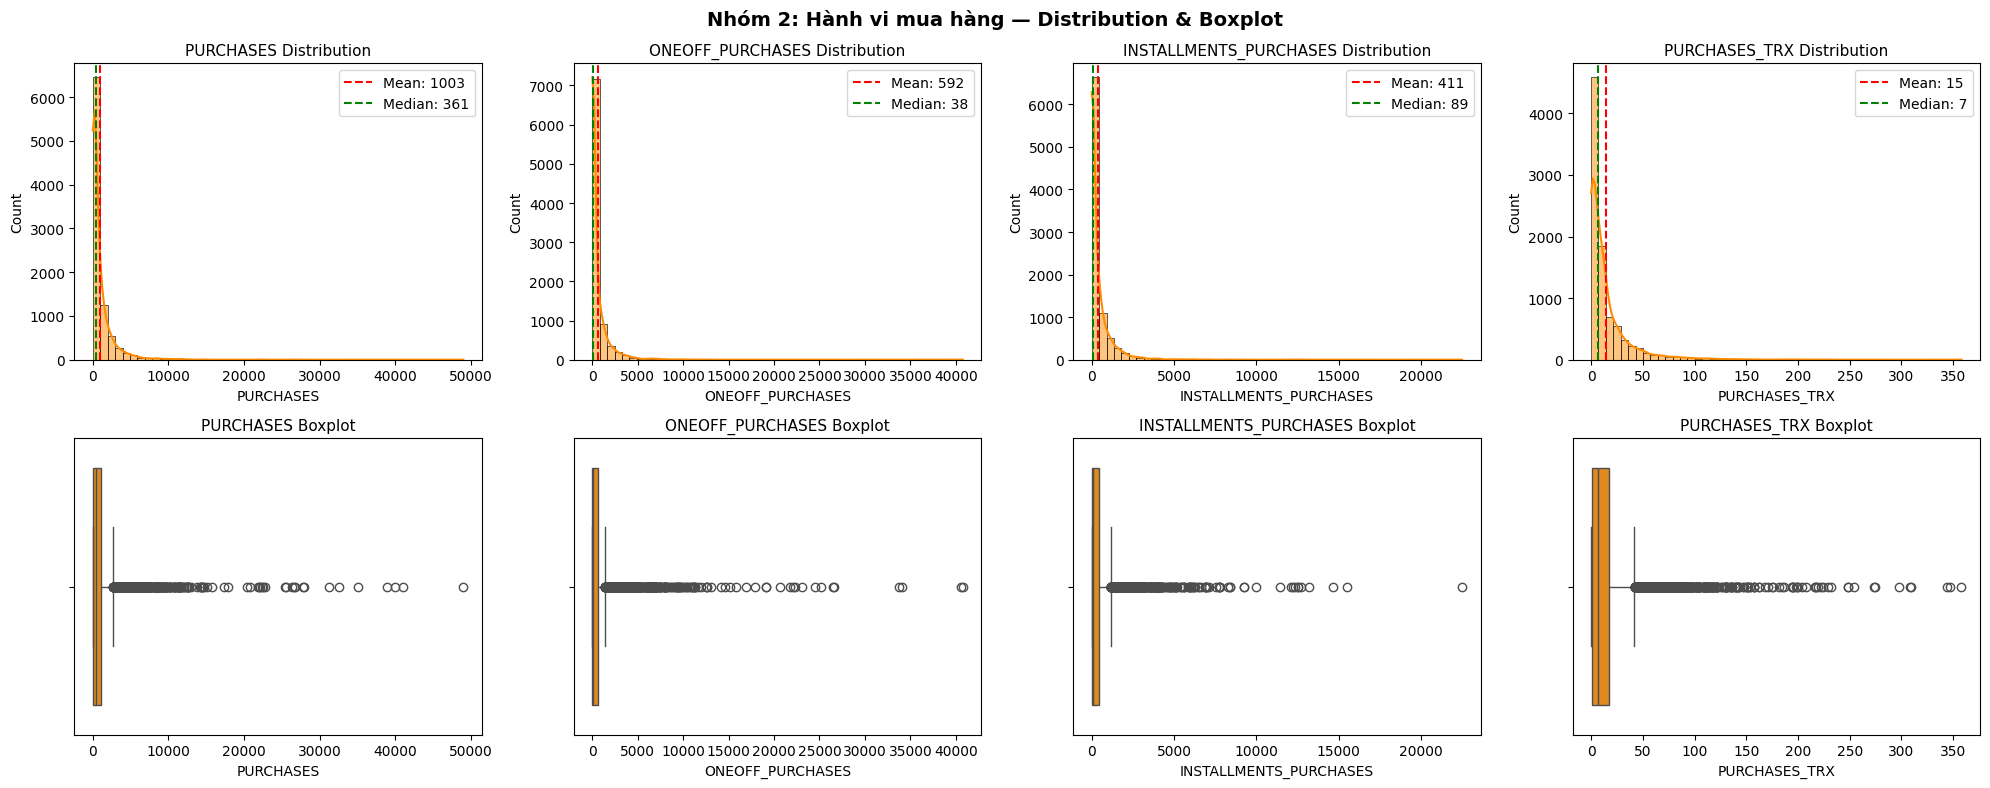

In [145]:
# =============================================
# Nhóm 2: Hành vi mua hàng (PURCHASES)
# =============================================
purchase_cols = ['PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'PURCHASES_TRX']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, col in enumerate(purchase_cols):
    # Hàng 1: Histogram + KDE
    sns.histplot(df[col], bins=50, kde=True, ax=axes[0, i], color='darkorange')
    axes[0, i].set_title(f'{col} Distribution', fontsize=11)
    axes[0, i].set_xlabel(col)
    axes[0, i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.0f}')
    axes[0, i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.0f}')
    axes[0, i].legend()

    # Hàng 2: Boxplot
    sns.boxplot(x=df[col], ax=axes[1, i], color='darkorange')
    axes[1, i].set_title(f'{col} Boxplot', fontsize=11)
    axes[1, i].set_xlabel(col)

plt.suptitle('Nhóm 2: Hành vi mua hàng — Distribution & Boxplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



### Nhóm 2 — Kết luận: Hành vi mua hàng

| Feature | Mean | Median | Kết luận |
|---------|------|--------|---------|
| **PURCHASES** | $1,003 | $361 | Lệch phải nặng, đa số khách mua ít (<$500) |
| **ONEOFF_PURCHASES** | $592 | $38 | >50% khách không mua đứt |
| **INSTALLMENTS_PURCHASES** | $411 | $89 | Trả góp phổ biến hơn mua đứt (về tần suất) |
| **PURCHASES_TRX** | 14.7 | 7 | 25% khách chỉ mua 1 lần/6 tháng |

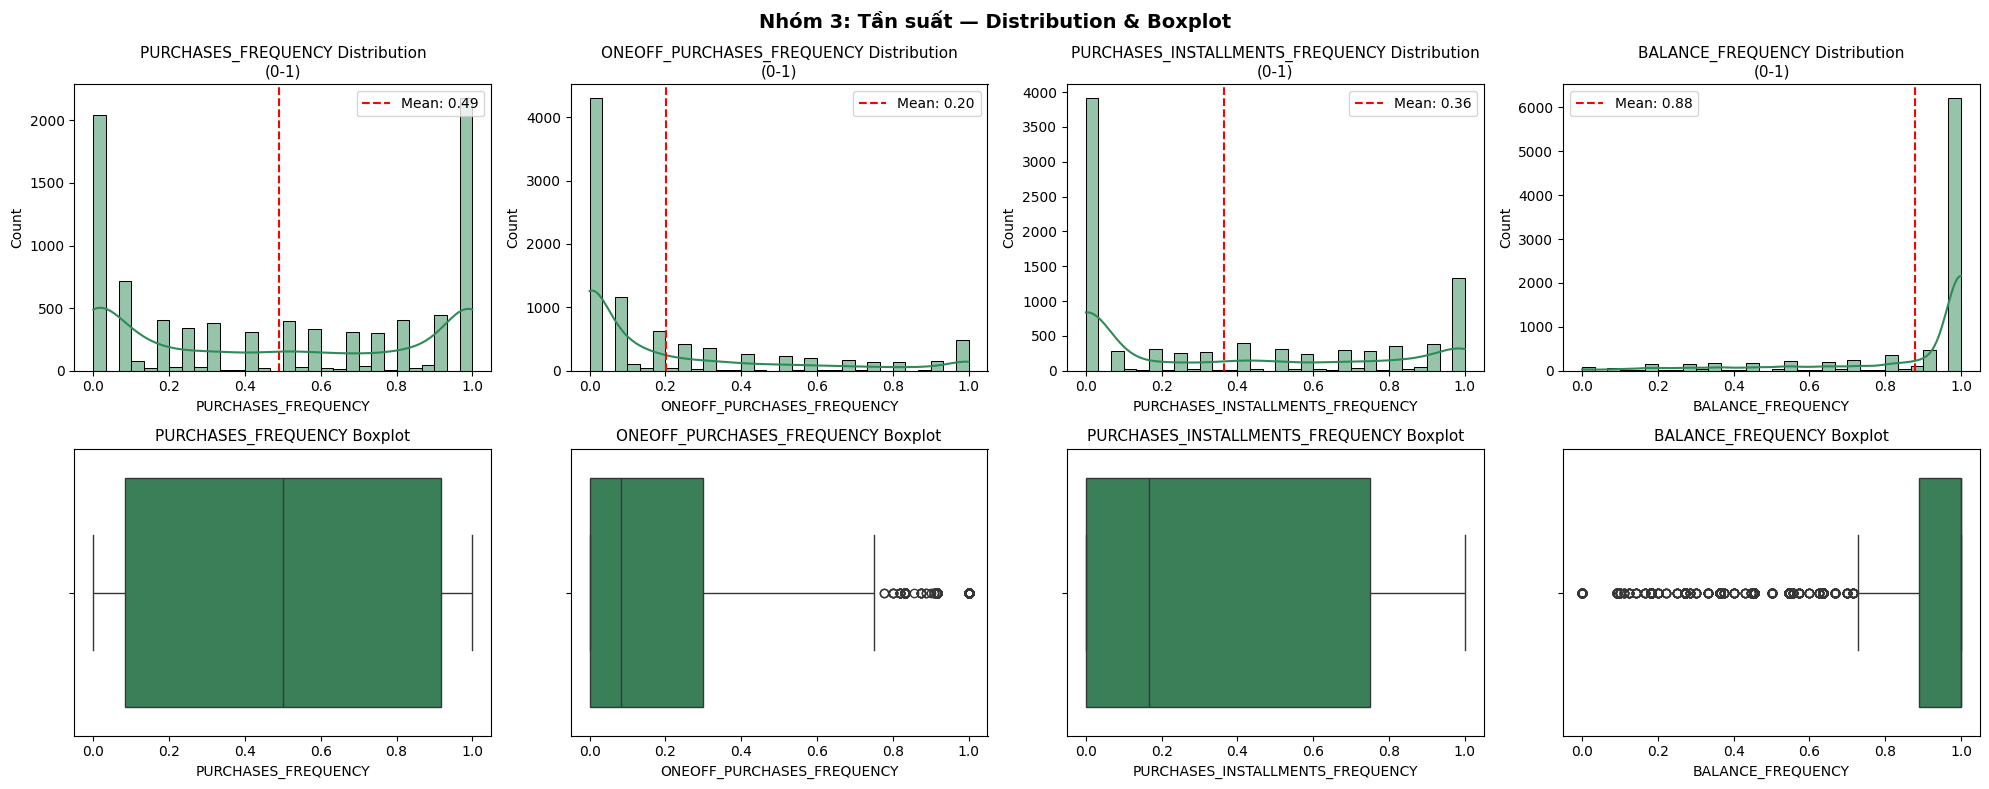

In [146]:
# =============================================
# Nhóm 3: Tần suất (FREQUENCY)
# =============================================
freq_cols = ['PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
             'PURCHASES_INSTALLMENTS_FREQUENCY', 'BALANCE_FREQUENCY']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, col in enumerate(freq_cols):
    # Hàng 1: Histogram + KDE
    sns.histplot(df[col], bins=30, kde=True, ax=axes[0, i], color='seagreen')
    axes[0, i].set_title(f'{col} Distribution\n(0-1)', fontsize=11)
    axes[0, i].set_xlabel(col)
    axes[0, i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[0, i].legend()

    # Hàng 2: Boxplot
    sns.boxplot(x=df[col], ax=axes[1, i], color='seagreen')
    axes[1, i].set_title(f'{col} Boxplot', fontsize=11)
    axes[1, i].set_xlabel(col)

plt.suptitle('Nhóm 3: Tần suất — Distribution & Boxplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



### Nhóm 3 — Kết luận: Tần suất

| Feature | Mean | Kết luận |
|---------|------|---------|
| **PURCHASES_FREQUENCY** | 0.49 | Khách mua ít hơn nửa thời gian |
| **ONEOFF_PURCHASES_FREQUENCY** | 0.20 | Ít mua đứt, chuộng trả góp |
| **PURCHASES_INSTALLMENTS_FREQUENCY** | 0.36 | Trả góp phổ biến hơn mua đứt |
| **BALANCE_FREQUENCY** | 0.88 | Hầu hết khách thanh toán thường xuyên |

> **Quan hệ:** INSTALL_FREQ (0.36) > ONEOFF_FREQ (0.20) → Khách **ưa trả góp hơn mua đứt**

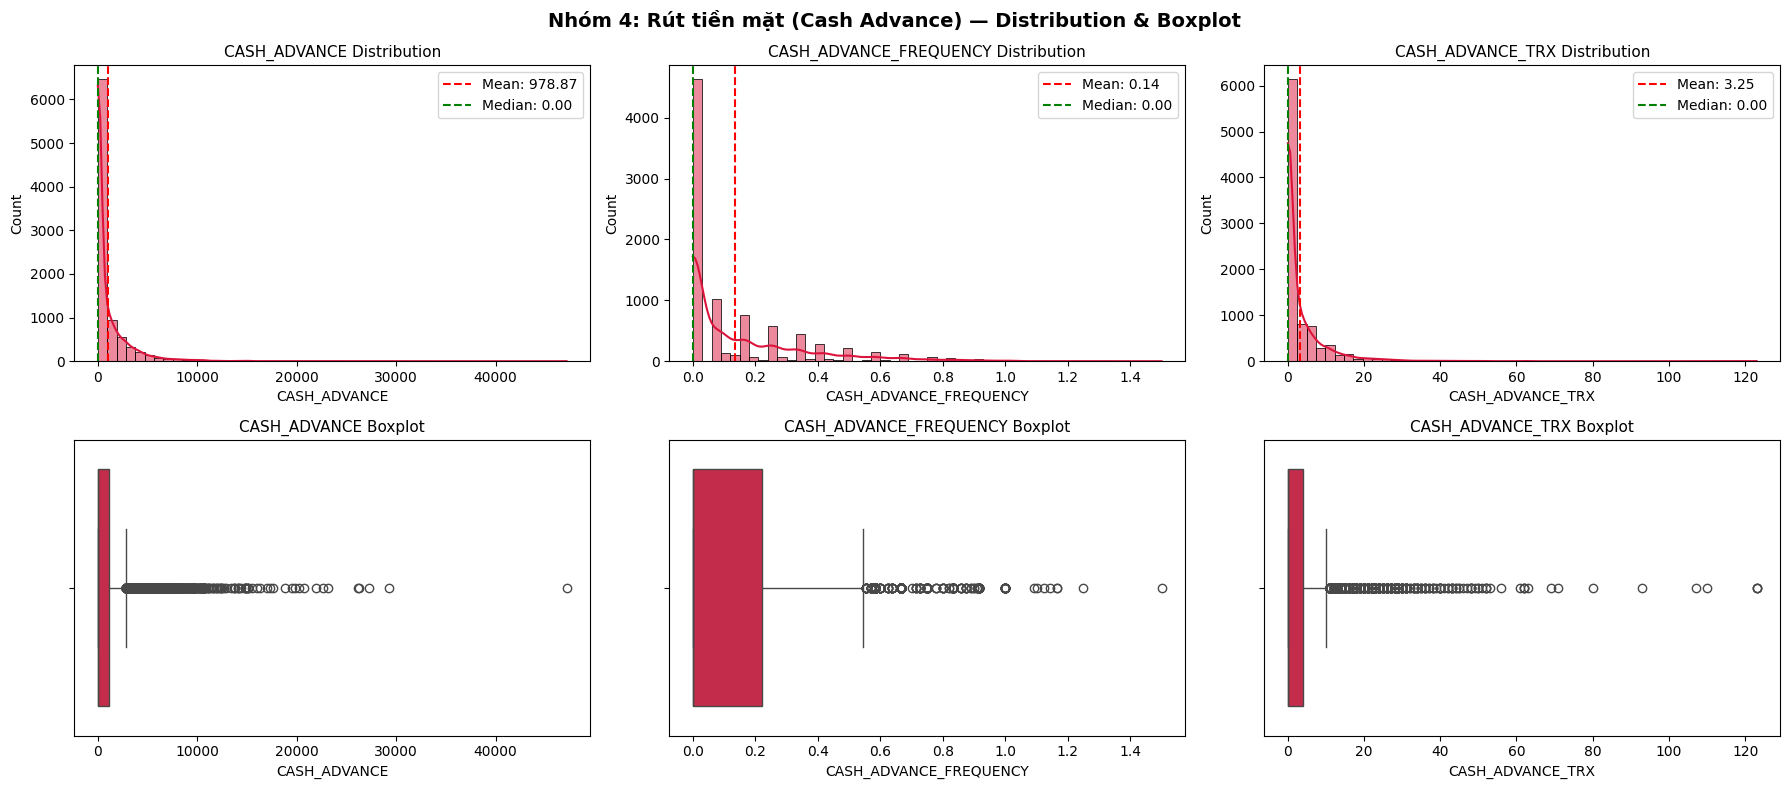

In [147]:
# =============================================
# Nhóm 4: Rút tiền mặt (CASH ADVANCE)
# =============================================
cash_cols = ['CASH_ADVANCE', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, col in enumerate(cash_cols):
    # Hàng 1: Histogram + KDE
    sns.histplot(df[col], bins=50, kde=True, ax=axes[0, i], color='crimson')
    axes[0, i].set_title(f'{col} Distribution', fontsize=11)
    axes[0, i].set_xlabel(col)
    axes[0, i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[0, i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
    axes[0, i].legend()

    # Hàng 2: Boxplot
    sns.boxplot(x=df[col], ax=axes[1, i], color='crimson')
    axes[1, i].set_title(f'{col} Boxplot', fontsize=11)
    axes[1, i].set_xlabel(col)

plt.suptitle('Nhóm 4: Rút tiền mặt (Cash Advance) — Distribution & Boxplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Nhóm 4 — Kết luận: Rút tiền mặt (Cash Advance)

| Feature | Mean | Median | Kết luận |
|---------|------|--------|---------|
| **CASH_ADVANCE** | $979 | $0| >50% khách KHÔNG rút tiền mặt |
| **CASH_ADVANCE_FREQUENCY** | 0.14 | 0 | Hiếm khi rút tiền khi có giao dịch |
| **CASH_ADVANCE_TRX** | 3.2 | 0 | 50% khách có 0 giao dịch rút tiền |

 Nhóm rút tiền mặt là thiểu số nhưng rất nặng (max = $47,137) → Đây là nhóm rủi ro tài chính

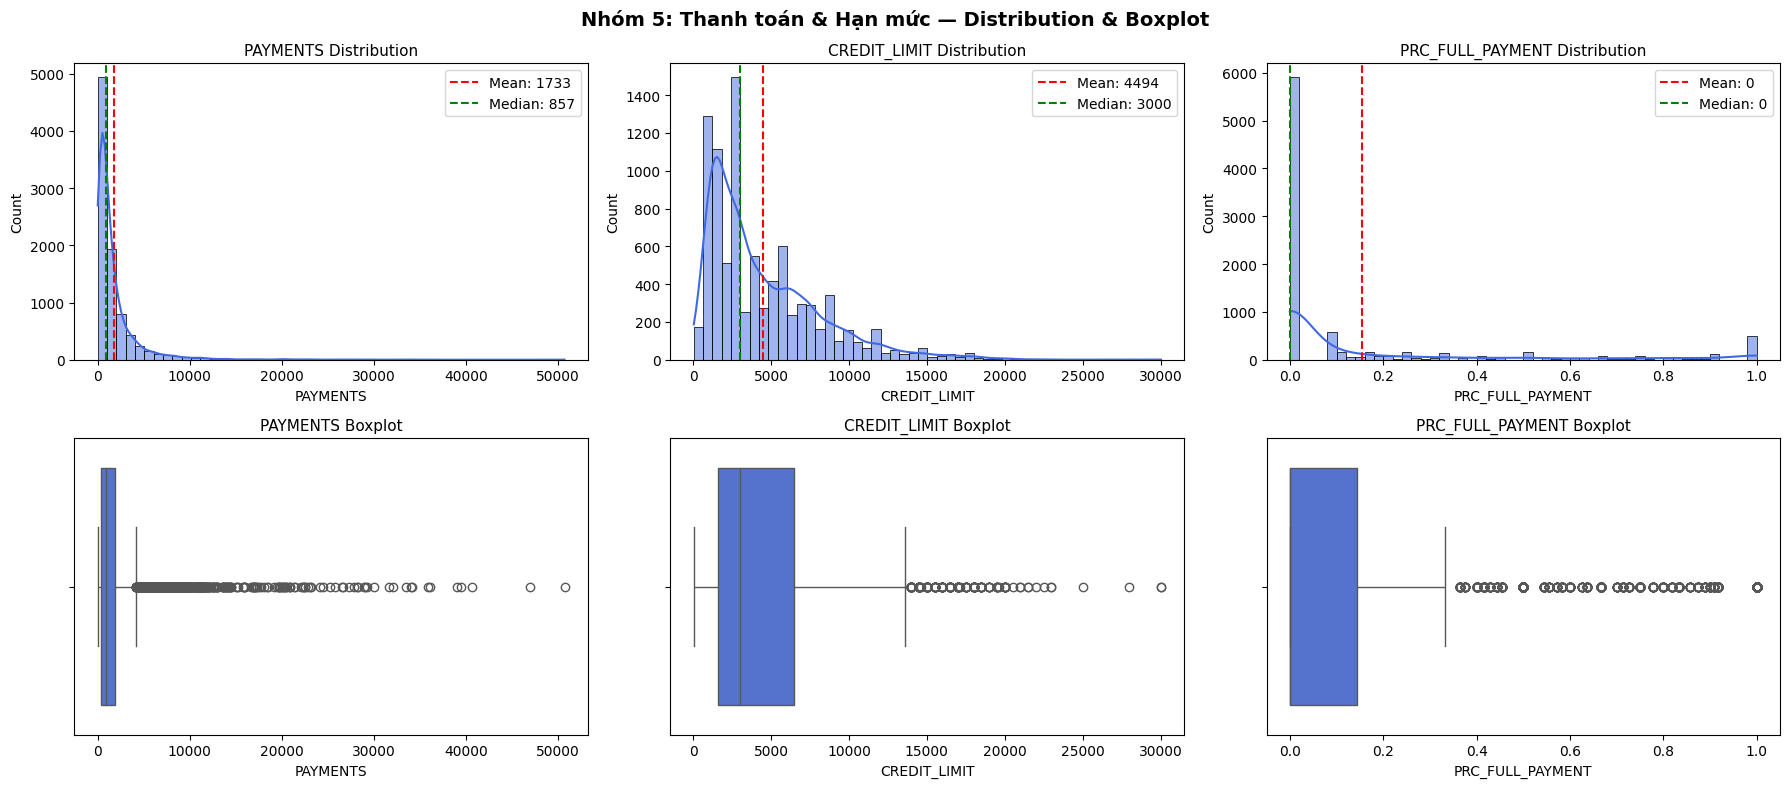

→ PAYMENTS: Mean > BALANCE Mean → Khách trả nhiều hơn nợ
→ CREDIT_LIMIT: Hầu hết khách có hạn mức < $5,000 (median = $3,000)
→ PRC_FULL_PAYMENT: Median=0 → >50% khách KHÔNG trả đủ nợ


In [148]:
# =============================================
# Nhóm 5: Thanh toán & Hạn mức (PAYMENTS)
# =============================================
pay_cols = ['PAYMENTS', 'CREDIT_LIMIT', 'PRC_FULL_PAYMENT']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, col in enumerate(pay_cols):
    # Hàng 1: Histogram + KDE
    sns.histplot(df[col], bins=50, kde=True, ax=axes[0, i], color='royalblue')
    axes[0, i].set_title(f'{col} Distribution', fontsize=11)
    axes[0, i].set_xlabel(col)
    axes[0, i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.0f}')
    axes[0, i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.0f}')
    axes[0, i].legend()

    # Hàng 2: Boxplot
    sns.boxplot(x=df[col], ax=axes[1, i], color='royalblue')
    axes[1, i].set_title(f'{col} Boxplot', fontsize=11)
    axes[1, i].set_xlabel(col)

plt.suptitle('Nhóm 5: Thanh toán & Hạn mức — Distribution & Boxplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("→ PAYMENTS: Mean > BALANCE Mean → Khách trả nhiều hơn nợ")
print("→ CREDIT_LIMIT: Hầu hết khách có hạn mức < $5,000 (median = $3,000)")
print("→ PRC_FULL_PAYMENT: Median=0 → >50% khách KHÔNG trả đủ nợ")

### Nhóm 5 — Kết luận: Thanh toán & Hạn mức

| Feature | Mean | Median | Kết luận |
|---------|------|--------|---------|
| **PAYMENTS** | $1,733 | $857 | Mean > BALANCE → Khách trả nhiều hơn nợ |
| **CREDIT_LIMIT** | $4,494 | $3,000 | Hầu hết khách có hạn mức thấp (<$5,000) |
| **PRC_FULL_PAYMENT** | 15.4% | **0** | >50% khách KHÔNG trả đủ nợ |

> **Quan hệ quan trọng:**
> - `PAYMENTS_mean ($1,733) > BALANCE_mean ($1,564)` → Khách nhìn chung có trách nhiệm tài chính
> - `PRC_FULL_PAYMENT median = 0` → **Rủi ro** — hơn nửa khách không trả hết dư nợ

## Xử lý Outliers bằng Log Transform


In [149]:
# =============================================
# ÁP DỤNG LOG TRANSFORM
# =============================================
from scipy.stats import skew

# Lấy numerical columns (trừ Cluster nếu có)
num_cols = [col for col in df.columns if col != 'Cluster']

# Columns KHÔNG cần log transform (đã bounded 0-1)
freq_cols = ['BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
             'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
             'PRC_FULL_PAYMENT', 'TENURE']

# Columns CẦN log transform (amount/ count — lệch phải)
amount_cols = [col for col in num_cols if col not in freq_cols]

# Lưu df gốc trước khi transform
df_original = df.copy()

# Áp dụng log1p cho amount columns
df_log = df.copy()
for col in amount_cols:
    df_log[col] = np.log1p(df_log[col])

# So sánh skewness trước vs sau
print("=" * 60)
print("SKEWNESS TRƯỚC vs SAU LOG TRANSFORM")
print("=" * 60)
print(f"\n{'Feature':<30} {'Before':>10} {'After':>10} {'Giảm':>8}")
print("-" * 60)

for col in num_cols:
    before = abs(skew(df[col].dropna()))
    after = abs(skew(df_log[col].dropna()))
    reduced = (before - after) / before * 100
    print(f"{col:<30} {before:>10.3f} {after:>10.3f} {reduced:>7.1f}%")

print("-" * 60)


SKEWNESS TRƯỚC vs SAU LOG TRANSFORM

Feature                            Before      After     Giảm
------------------------------------------------------------
BALANCE                             2.393      0.861    64.0%
BALANCE_FREQUENCY                   2.023      2.023     0.0%
PURCHASES                           8.143      0.764    90.6%
ONEOFF_PURCHASES                   10.043      0.186    98.1%
INSTALLMENTS_PURCHASES              7.298      0.025    99.7%
CASH_ADVANCE                        5.166      0.263    94.9%
PURCHASES_FREQUENCY                 0.060      0.060     0.0%
ONEOFF_PURCHASES_FREQUENCY          1.535      1.535     0.0%
PURCHASES_INSTALLMENTS_FREQUENCY      0.509      0.509     0.0%
CASH_ADVANCE_FREQUENCY              1.828      1.828     0.0%
CASH_ADVANCE_TRX                    5.720      0.940    83.6%
PURCHASES_TRX                       4.630      0.033    99.3%
CREDIT_LIMIT                        1.522      0.102    93.3%
PAYMENTS                        

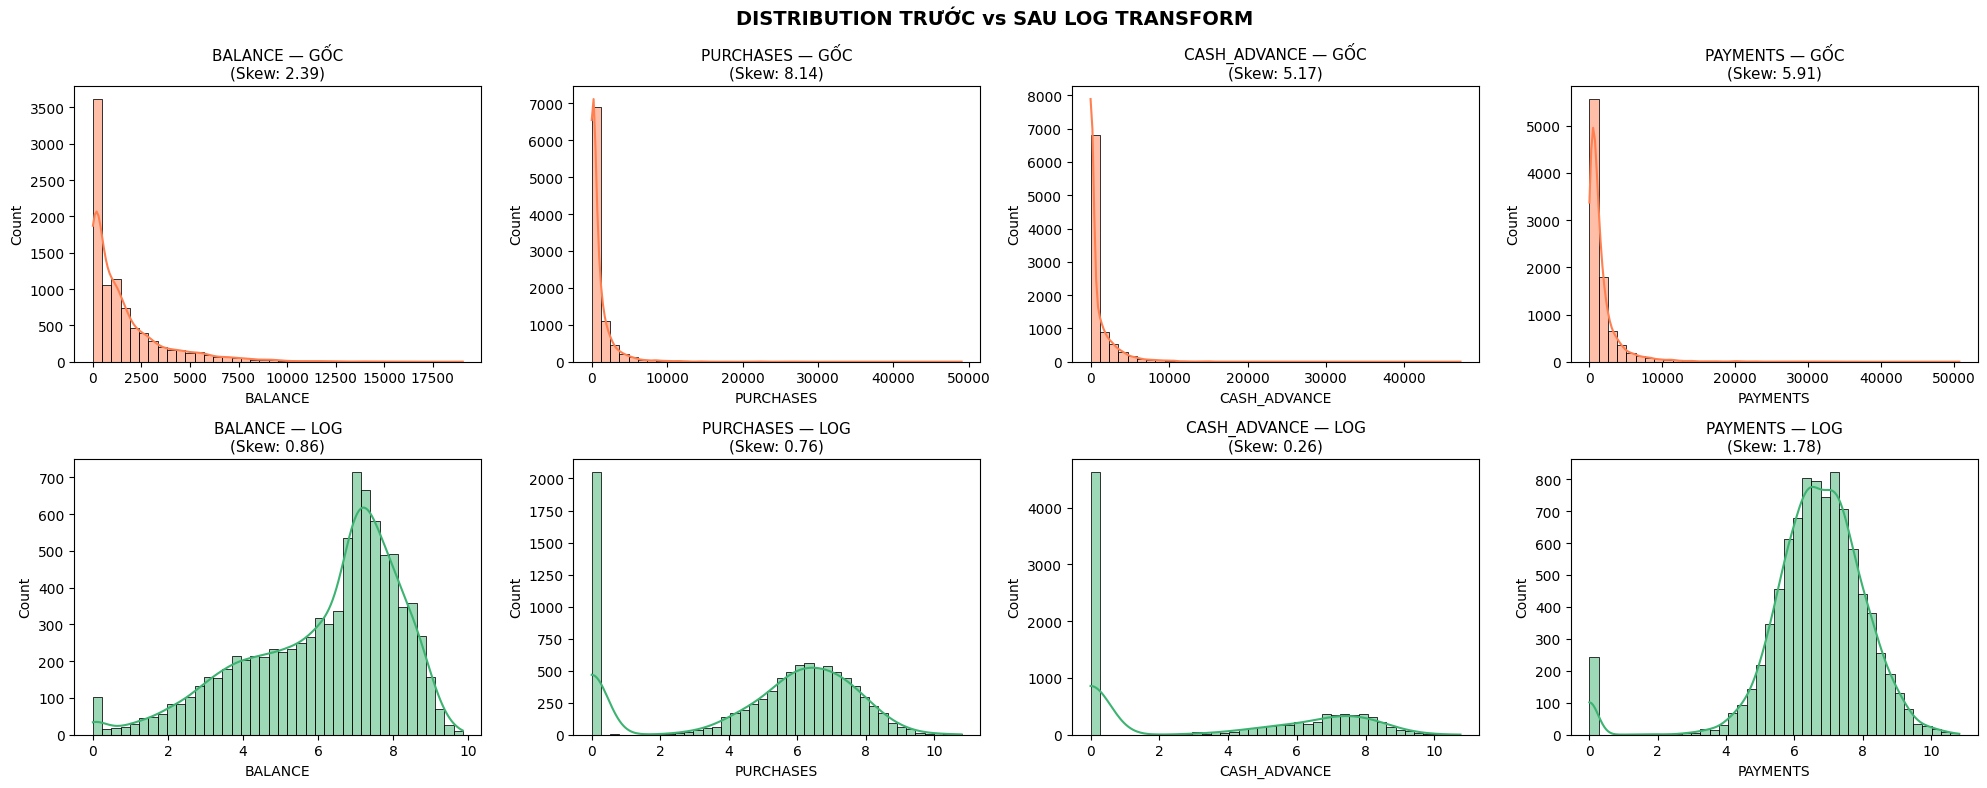

→ Phân phối sau log transform gần normal hơn → Tốt cho K-Means clustering


In [150]:
# =============================================
# TRƯỚC vs SAU: Distribution Comparison
# =============================================
key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PAYMENTS']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, col in enumerate(key_features):
    # Hàng 1: Distribution GỐC
    sns.histplot(df_original[col].dropna(), bins=40, kde=True, ax=axes[0, i], color='coral')
    axes[0, i].set_title(f'{col} — GỐC\n(Skew: {abs(skew(df_original[col])):.2f})', fontsize=11)
    axes[0, i].set_xlabel(col)

    # Hàng 2: Distribution SAU LOG
    sns.histplot(df_log[col].dropna(), bins=40, kde=True, ax=axes[1, i], color='mediumseagreen')
    axes[1, i].set_title(f'{col} — LOG\n(Skew: {abs(skew(df_log[col])):.2f})', fontsize=11)
    axes[1, i].set_xlabel(col)

plt.suptitle('DISTRIBUTION TRƯỚC vs SAU LOG TRANSFORM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("→ Phân phối sau log transform gần normal hơn → Tốt cho K-Means clustering")

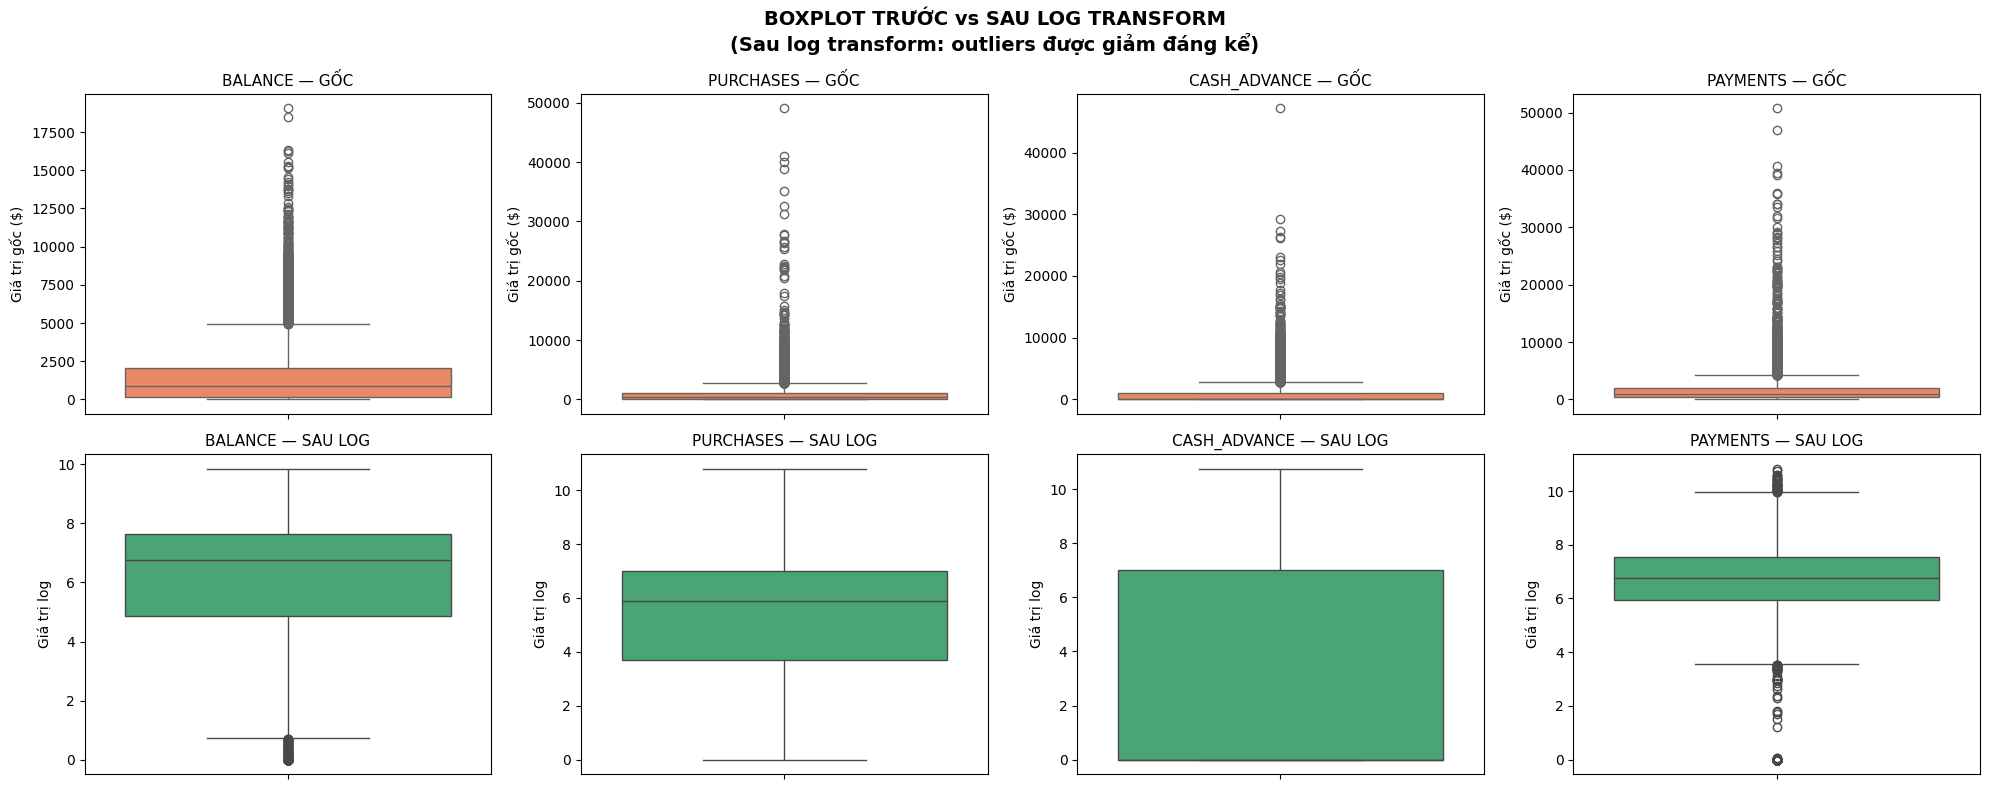

In [151]:
# =============================================
# TRƯỚC vs SAU: BOXPLOT COMPARISON
# =============================================
key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PAYMENTS']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, col in enumerate(key_features):
    # Hàng 1: Boxplot GỐC
    sns.boxplot(y=df_original[col], ax=axes[0, i], color='coral')
    axes[0, i].set_title(f'{col} — GỐC', fontsize=11)
    axes[0, i].set_ylabel('Giá trị gốc ($)')

    # Hàng 2: Boxplot SAU LOG
    sns.boxplot(y=df_log[col], ax=axes[1, i], color='mediumseagreen')
    axes[1, i].set_title(f'{col} — SAU LOG', fontsize=11)
    axes[1, i].set_ylabel('Giá trị log')

plt.suptitle('BOXPLOT TRƯỚC vs SAU LOG TRANSFORM\n(Sau log transform: outliers được giảm đáng kể)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


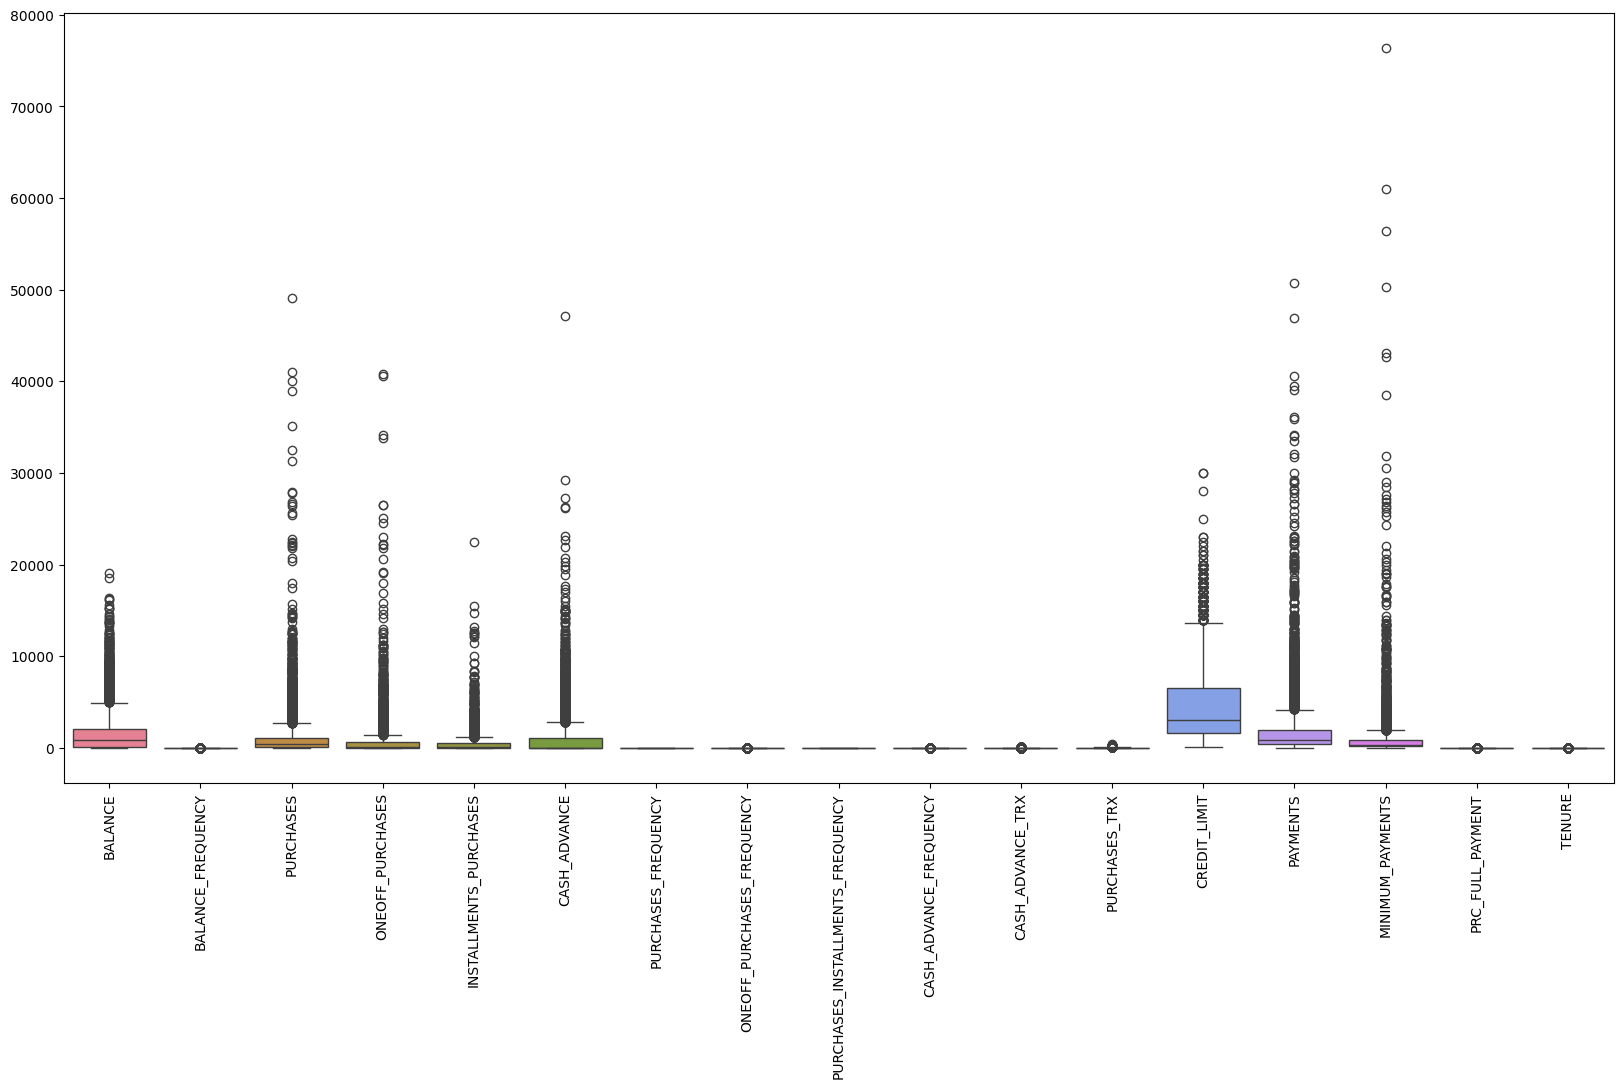

In [152]:
plt.figure(figsize=(20,10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

## Analyze the Categorical Variables

> Dataset không có biến categorical thuần (object/string). Vì vậy, ta sẽ **binning** các biến liên tục thành các nhóm có ý nghĩa, tương tự cách File 5 binned age thành `age_groups` và bmi thành `bmi_groups`.

### Chiến lược binning

Với dataset thẻ tín dụng, ta tạo các categorical groups dựa trên phân bố và ý nghĩa kinh doanh:

| Variable gốc | Tên nhóm | Cách phân nhóm | Ý nghĩa |
|---|---|---|---|
| **BALANCE** | `balance_group` | Q5 (quintiles) | Số dư nợ: Low → Very High |
| **PURCHASES** | `purchase_group` | Q4 (quartiles) | Mức chi tiêu: Low → High |
| **CREDIT_LIMIT** | `credit_group` | Q4 (quartiles) | Hạn mức: Low → High |
| **PAYMENTS** | `payment_group` | Q5 (quintiles) | Thanh toán: Low → Very High |
| **CASH_ADVANCE** | `cash_advance_group` | Custom: 0 / Low / High | Rút tiền mặt: có/không |
| **PURCHASES_TRX** | `tx_count_group` | Custom: <10 / 10-30 / >30 | Số lần giao dịch |
| **TENURE** | Giữ nguyên | discrete 6-12 | Thời gian sử dụng thẻ (tháng) |

In [153]:
# =============================================
# BINNING: Chuyển biến liên tục -> categorical
# =============================================

df_cat = df.copy()

# BALANCE: quintiles (5 nhóm)
df_cat['balance_group'] = pd.qcut(df_cat['BALANCE'], q=5,
                                  labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# PURCHASES: quartiles (4 nhóm)
df_cat['purchase_group'] = pd.qcut(df_cat['PURCHASES'], q=4,
                                    labels=['Low', 'Medium', 'High', 'Very High'])

# CREDIT_LIMIT: quartiles (4 nhóm)
df_cat['credit_group'] = pd.qcut(df_cat['CREDIT_LIMIT'], q=4,
                                 labels=['Low', 'Medium', 'High', 'Very High'])

# PAYMENTS: quintiles (5 nhóm)
df_cat['payment_group'] = pd.qcut(df_cat['PAYMENTS'], q=5,
                                   labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# CASH_ADVANCE: custom groups (No / Low / High)
def categorize_cash_advance(x):
    if x == 0:
        return 'No Cash Advance'
    elif x < df_cat['CASH_ADVANCE'].quantile(0.75):
        return 'Low Cash Advance'
    else:
        return 'High Cash Advance'

df_cat['cash_advance_group'] = df_cat['CASH_ADVANCE'].apply(categorize_cash_advance)

# PURCHASES_TRX: custom groups
def categorize_tx_count(x):
    if x < 10:
        return 'Low (<10)'
    elif x <= 30:
        return 'Medium (10-30)'
    else:
        return 'High (>30)'

df_cat['tx_count_group'] = df_cat['PURCHASES_TRX'].apply(categorize_tx_count)

# Chọn các categorical columns để phân tích
cat_cols = ['balance_group', 'purchase_group', 'credit_group',
            'payment_group', 'cash_advance_group', 'tx_count_group', 'TENURE']

df_cat[cat_cols].head(10)

,balance_group,purchase_group,credit_group,payment_group,cash_advance_group,tx_count_group,TENURE
0,Very Low,Medium,Low,Very Low,No Cash Advance,Low (<10),12
1,Very High,Low,Very High,Very High,High Cash Advance,Low (<10),12
2,High,High,Very High,Low,No Cash Advance,Medium (10-30),12
3,High,Very High,Very High,Very Low,Low Cash Advance,Low (<10),12
4,Medium,Low,Low,Medium,No Cash Advance,Low (<10),12
5,High,Very High,Medium,High,No Cash Advance,Low (<10),12
6,Medium,Very High,Very High,Very High,No Cash Advance,High (>30),12
7,High,High,Medium,Medium,No Cash Advance,Medium (10-30),12
8,Medium,High,Very High,Medium,No Cash Advance,Low (<10),12
9,Low,Very High,Very High,Medium,No Cash Advance,Low (<10),12


/tmp/ipykernel_56027/4120377549.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=list_axes[index], x=df_count.values, y=order, alpha=0.8, palette='mako')
/tmp/ipykernel_56027/4120377549.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=list_axes[index], x=df_count.values, y=order, alpha=0.8, palette='mako')
/tmp/ipykernel_56027/4120377549.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=list_axes[index], x=df_count.values, y=order, alpha=0.8, palette='mako')
/tmp/ipykernel_56027/4120377549.py:22: FutureWarning: 

Passing 

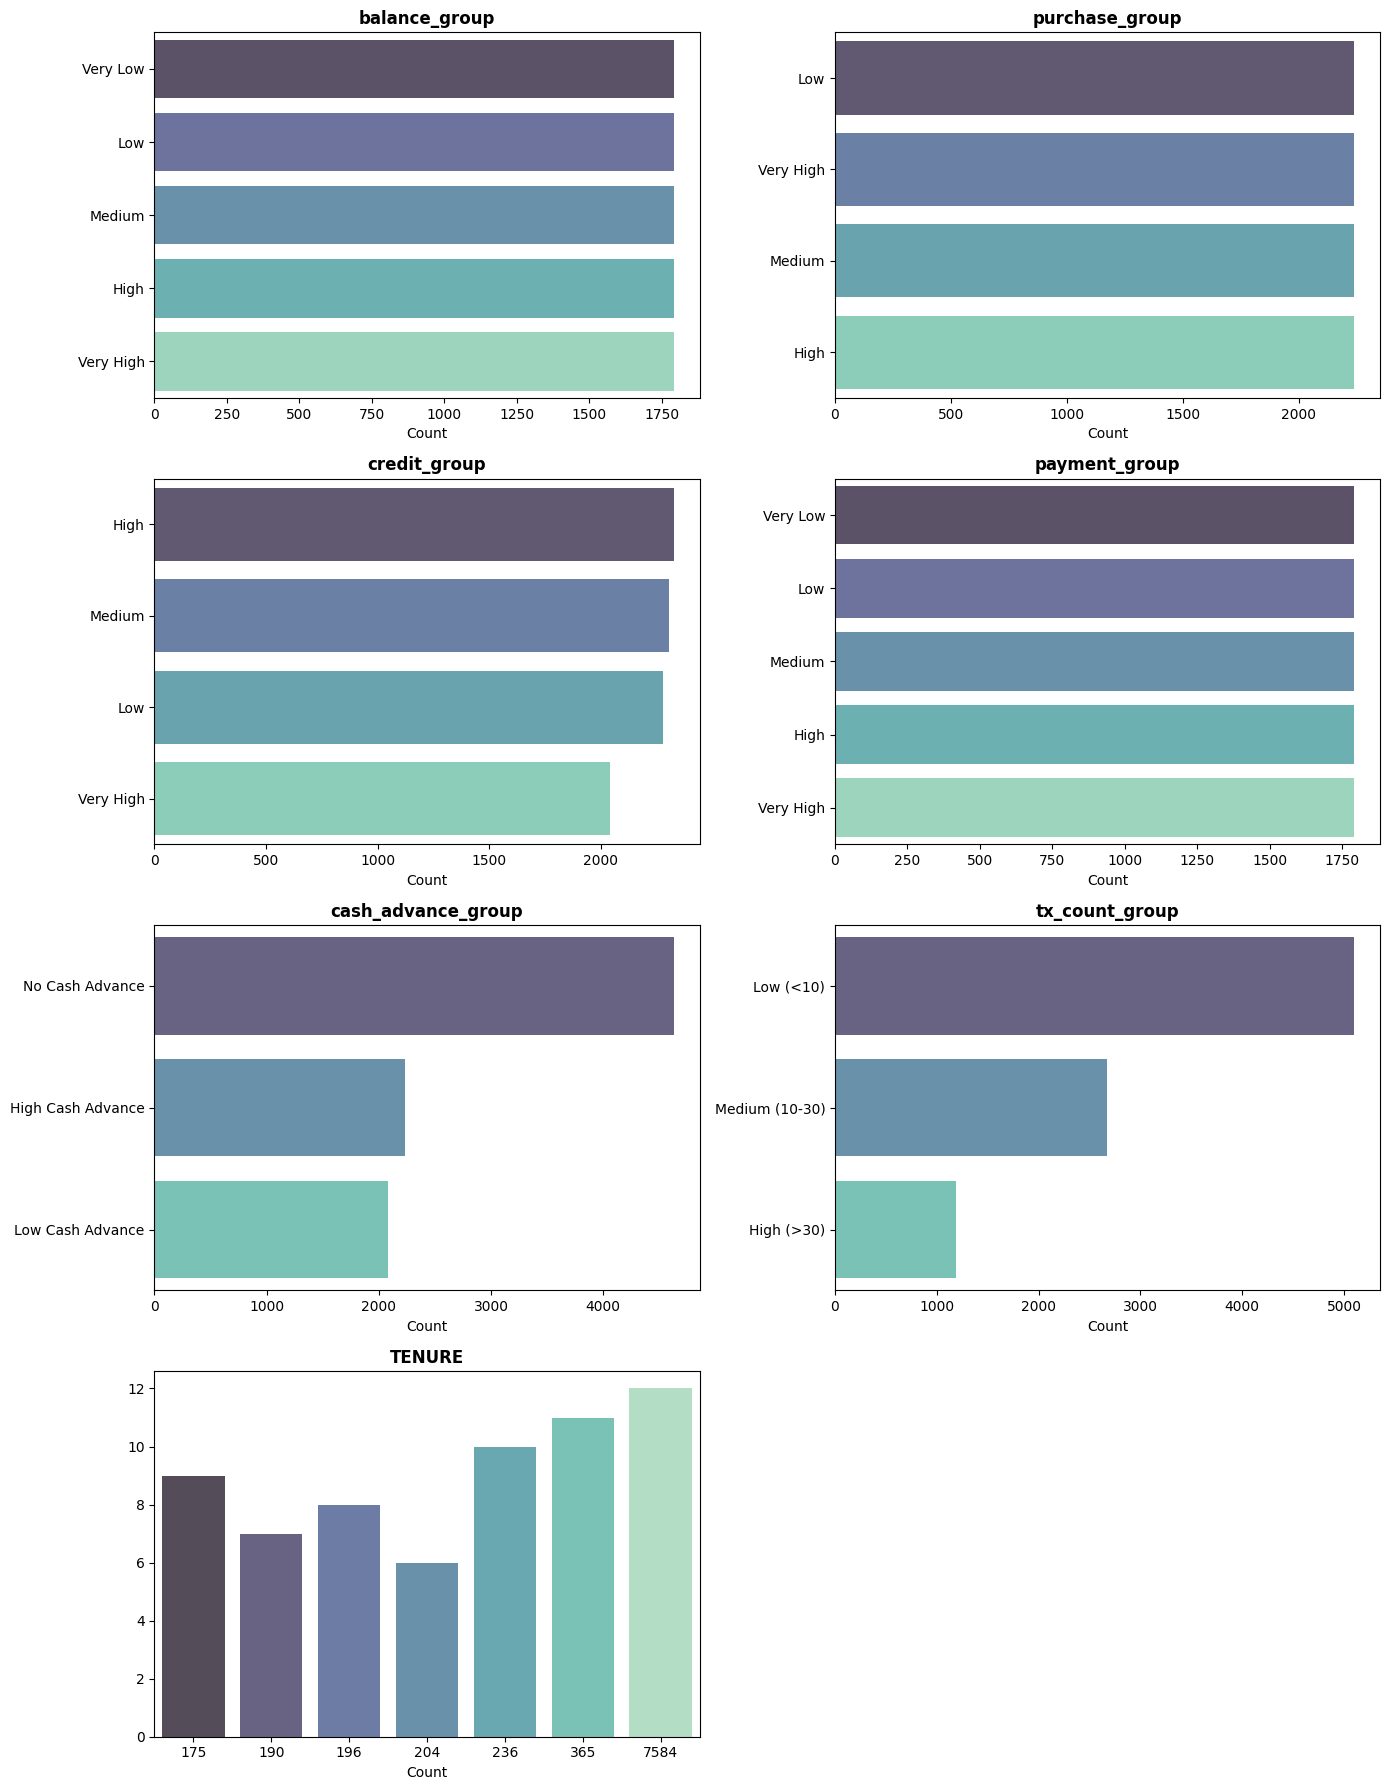

In [154]:
# =============================================
# Trực quan hóa: Bar chart cho categorical variables
# =============================================
cat_df = df_cat[cat_cols].copy()

num_plot = len(cat_df.columns)
num_cols_plot = min(num_plot, 2)
num_rows_plot = int(np.ceil(num_plot / num_cols_plot))

fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(14, 18))

if isinstance(axes, np.ndarray):
    list_axes = list(axes.flat)
else:
    list_axes = [axes]

for index, col in enumerate(cat_df.columns):
    df_count = df_cat[col].value_counts()

    # Sắp xếp theo thứ tự có ý nghĩa
    order = df_count.index.tolist()
    sns.barplot(ax=list_axes[index], x=df_count.values, y=order, alpha=0.8, palette='mako')
    list_axes[index].set_title(col, fontsize=12, fontweight='bold')
    list_axes[index].tick_params(axis='x', labelsize=10)
    list_axes[index].tick_params(axis='y', labelsize=10)
    list_axes[index].set_xlabel('Count', fontsize=10)

# Ẩn ô trống thừa
for i in range(num_plot, len(list_axes)):
    list_axes[i].set_visible(False)

fig.tight_layout()
plt.show()

In [155]:
# =============================================
# Tần suất (Frequency) của các biến categorical
# =============================================
print("=" * 70)
print("FREQUENCY CỦA CÁC BIẾN CATEGORICAL")
print("=" * 70)

for col in cat_cols:
    temp_df = df_cat[col].value_counts().rename_axis(col).reset_index(name='counts')
    temp_df['frequency (%)'] = round(temp_df['counts'] / len(df_cat) * 100, 2)
    print(f"\n {col}:")
    print(temp_df.to_string(index=False))

FREQUENCY CỦA CÁC BIẾN CATEGORICAL

 balance_group:
balance_group  counts  frequency (%)
     Very Low    1790           20.0
          Low    1790           20.0
       Medium    1790           20.0
         High    1790           20.0
    Very High    1790           20.0

 purchase_group:
purchase_group  counts  frequency (%)
           Low    2238          25.01
     Very High    2238          25.01
        Medium    2237          24.99
          High    2237          24.99

 credit_group:
credit_group  counts  frequency (%)
        High    2325          25.98
      Medium    2304          25.74
         Low    2279          25.46
   Very High    2042          22.82

 payment_group:
payment_group  counts  frequency (%)
     Very Low    1790           20.0
          Low    1790           20.0
       Medium    1790           20.0
         High    1790           20.0
    Very High    1790           20.0

 cash_advance_group:
cash_advance_group  counts  frequency (%)
   No Cash Advance 

/tmp/ipykernel_56027/3329732624.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='balance_group', y='PURCHASES', data=df_cat, ax=axes[0, 1], palette='mako',
/tmp/ipykernel_56027/3329732624.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='balance_group', y='PURCHASES', data=df_cat, ax=axes[0, 2], palette='mako',
/tmp/ipykernel_56027/3329732624.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='purchase_group', y='CREDIT_LIMIT', data=df_cat, ax=axes[1, 1], palette='mako',
/tmp/ipykernel_56027/3329732624.py:40: FutureWarning: 

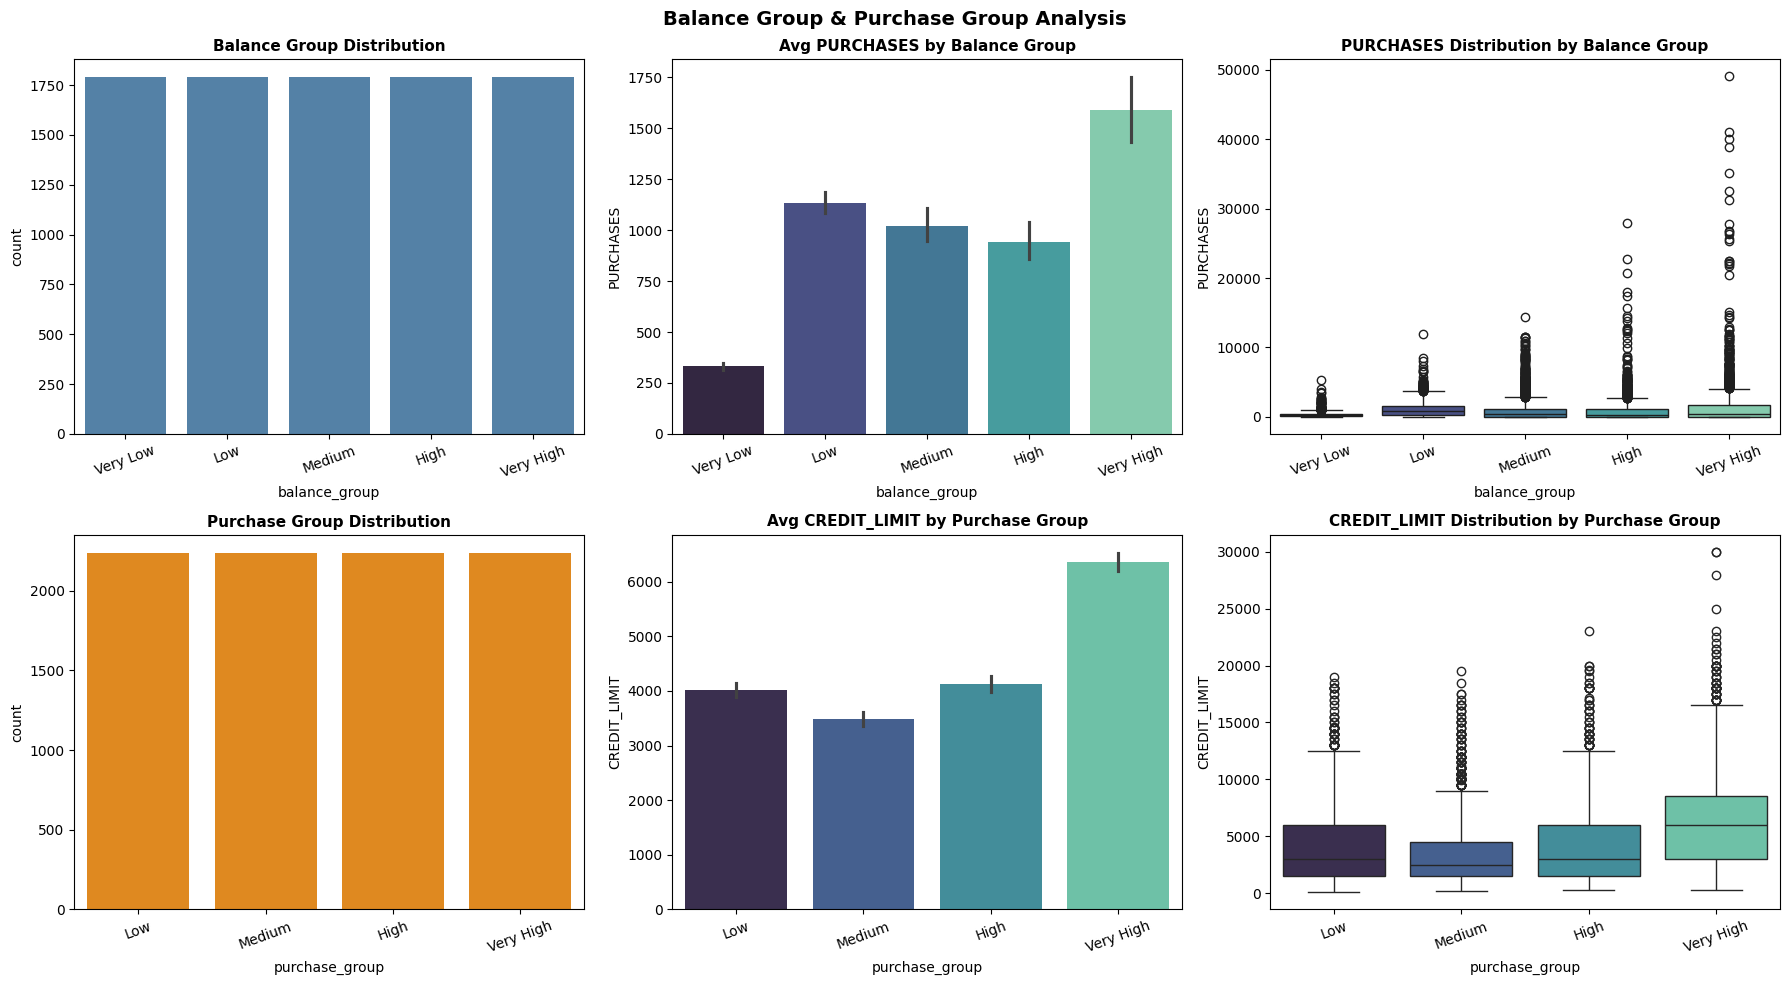

In [156]:
# =============================================
# Chi tiết từng biến: balance_group vs PURCHASES & CREDIT_LIMIT
# =============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

order_balance = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
order_purchase = ['Low', 'Medium', 'High', 'Very High']

# 1. BALANCE GROUP: phân bố count → dùng countplot (không phải histplot)
sns.countplot(x='balance_group', data=df_cat, ax=axes[0, 0], color='steelblue',
              order=order_balance)
axes[0, 0].set_title('Balance Group Distribution', fontsize=11, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=20)

# 2. BALANCE GROUP: trung bình PURCHASES theo nhóm
sns.barplot(x='balance_group', y='PURCHASES', data=df_cat, ax=axes[0, 1], palette='mako',
            order=order_balance)
axes[0, 1].set_title('Avg PURCHASES by Balance Group', fontsize=11, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=20)

# 3. BALANCE GROUP: boxplot PURCHASES
sns.boxplot(x='balance_group', y='PURCHASES', data=df_cat, ax=axes[0, 2], palette='mako',
            order=order_balance)
axes[0, 2].set_title('PURCHASES Distribution by Balance Group', fontsize=11, fontweight='bold')
axes[0, 2].tick_params(axis='x', rotation=20)

# 4. PURCHASE GROUP: phân bố count → dùng countplot
sns.countplot(x='purchase_group', data=df_cat, ax=axes[1, 0], color='darkorange',
             order=order_purchase)
axes[1, 0].set_title('Purchase Group Distribution', fontsize=11, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=20)

# 5. PURCHASE GROUP: trung bình CREDIT_LIMIT theo nhóm
sns.barplot(x='purchase_group', y='CREDIT_LIMIT', data=df_cat, ax=axes[1, 1], palette='mako',
            order=order_purchase)
axes[1, 1].set_title('Avg CREDIT_LIMIT by Purchase Group', fontsize=11, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=20)

# 6. PURCHASE GROUP: boxplot CREDIT_LIMIT
sns.boxplot(x='purchase_group', y='CREDIT_LIMIT', data=df_cat, ax=axes[1, 2], palette='mako',
            order=order_purchase)
axes[1, 2].set_title('CREDIT_LIMIT Distribution by Purchase Group', fontsize=11, fontweight='bold')
axes[1, 2].tick_params(axis='x', rotation=20)

plt.suptitle('Balance Group & Purchase Group Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_56027/3855666141.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cash_advance_group', y='BALANCE', data=df_cat, ax=axes[0, 1], palette='mako', order=order_ca)
/tmp/ipykernel_56027/3855666141.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cash_advance_group', y='BALANCE', data=df_cat, ax=axes[0, 2], palette='mako', order=order_ca)


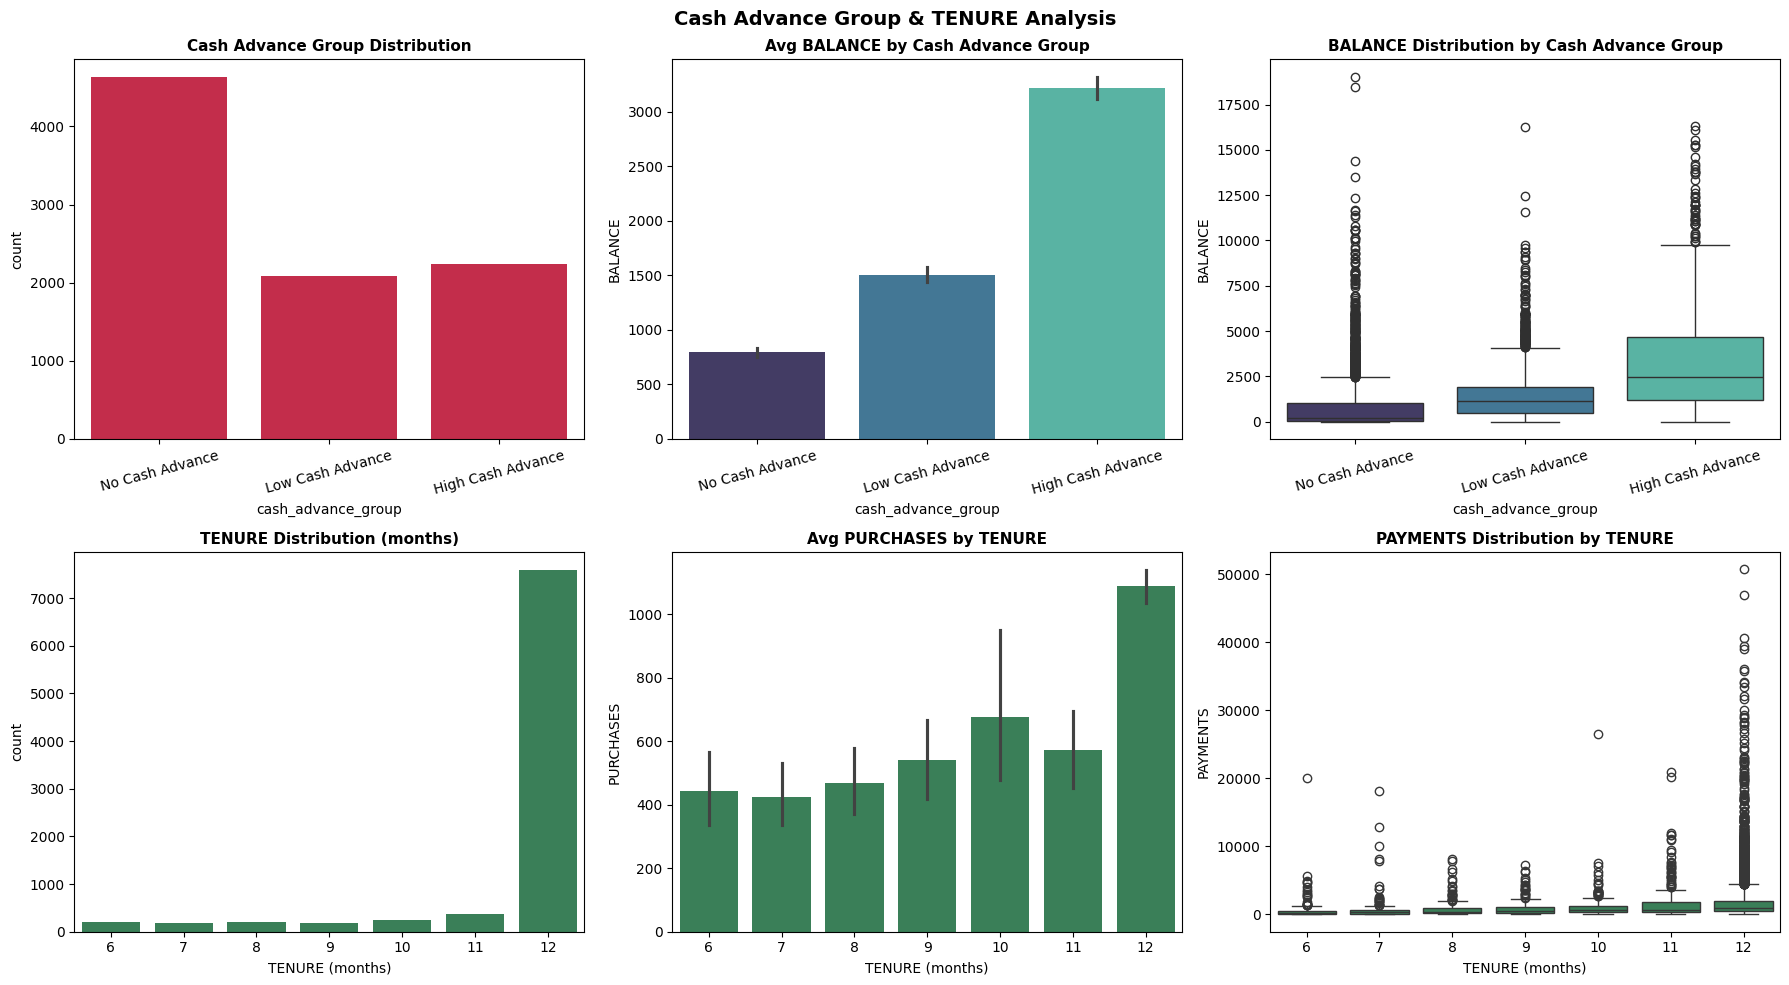

In [157]:
# =============================================
# Chi tiết: Cash Advance vs Tenure
# =============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

order_ca = ['No Cash Advance', 'Low Cash Advance', 'High Cash Advance']

# 1. CASH_ADVANCE_GROUP: count → dùng countplot
sns.countplot(x='cash_advance_group', data=df_cat, ax=axes[0, 0], color='crimson', order=order_ca)
axes[0, 0].set_title('Cash Advance Group Distribution', fontsize=11, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. CASH_ADVANCE_GROUP: trung bình BALANCE
sns.barplot(x='cash_advance_group', y='BALANCE', data=df_cat, ax=axes[0, 1], palette='mako', order=order_ca)
axes[0, 1].set_title('Avg BALANCE by Cash Advance Group', fontsize=11, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. CASH_ADVANCE_GROUP: boxplot BALANCE
sns.boxplot(x='cash_advance_group', y='BALANCE', data=df_cat, ax=axes[0, 2], palette='mako', order=order_ca)
axes[0, 2].set_title('BALANCE Distribution by Cash Advance Group', fontsize=11, fontweight='bold')
axes[0, 2].tick_params(axis='x', rotation=15)

# 4. TENURE: count → dùng countplot
order_tenure = sorted(df_cat['TENURE'].unique())
sns.countplot(x='TENURE', data=df_cat, ax=axes[1, 0], color='seagreen', order=order_tenure)
axes[1, 0].set_title('TENURE Distribution (months)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('TENURE (months)')

# 5. TENURE: trung bình PURCHASES
sns.barplot(x='TENURE', y='PURCHASES', data=df_cat, ax=axes[1, 1], color='seagreen', order=order_tenure)
axes[1, 1].set_title('Avg PURCHASES by TENURE', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('TENURE (months)')

# 6. TENURE: boxplot PAYMENTS
sns.boxplot(x='TENURE', y='PAYMENTS', data=df_cat, ax=axes[1, 2], color='seagreen', order=order_tenure)
axes[1, 2].set_title('PAYMENTS Distribution by TENURE', fontsize=11, fontweight='bold')
axes[1, 2].set_xlabel('TENURE (months)')

plt.suptitle('Cash Advance Group & TENURE Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Kết luận Phân tích Categorical

- **Balance Group:** Phân bố đều nhau. Nhóm dư nợ cao chi tiêu nhiều hơn -> dấu hiệu rủi ro.
- **Purchase Group:** Nhóm chi tiêu cao được ngân hàng tin tưởng với hạn mức lớn hơn.
- **Cash Advance Group:** ~48% khách không bao giờ rút tiền mặt. Nhóm rút nhiều thường dư nợ cao -> cần theo dõi rủi ro.
- **TENURE:** Đa số khách dùng thẻ từ đầu (12 tháng), khách mới (6-10 tháng) có chi tiêu thấp hơn.

> **Insight cho Clustering:** `balance_group`, `cash_advance_group` -> rủi ro tài chính. `purchase_group`, `tx_count_group` -> hành vi chi tiêu. `TENURE` -> phân biệt khách mới/trung thành.

### Data Visualization

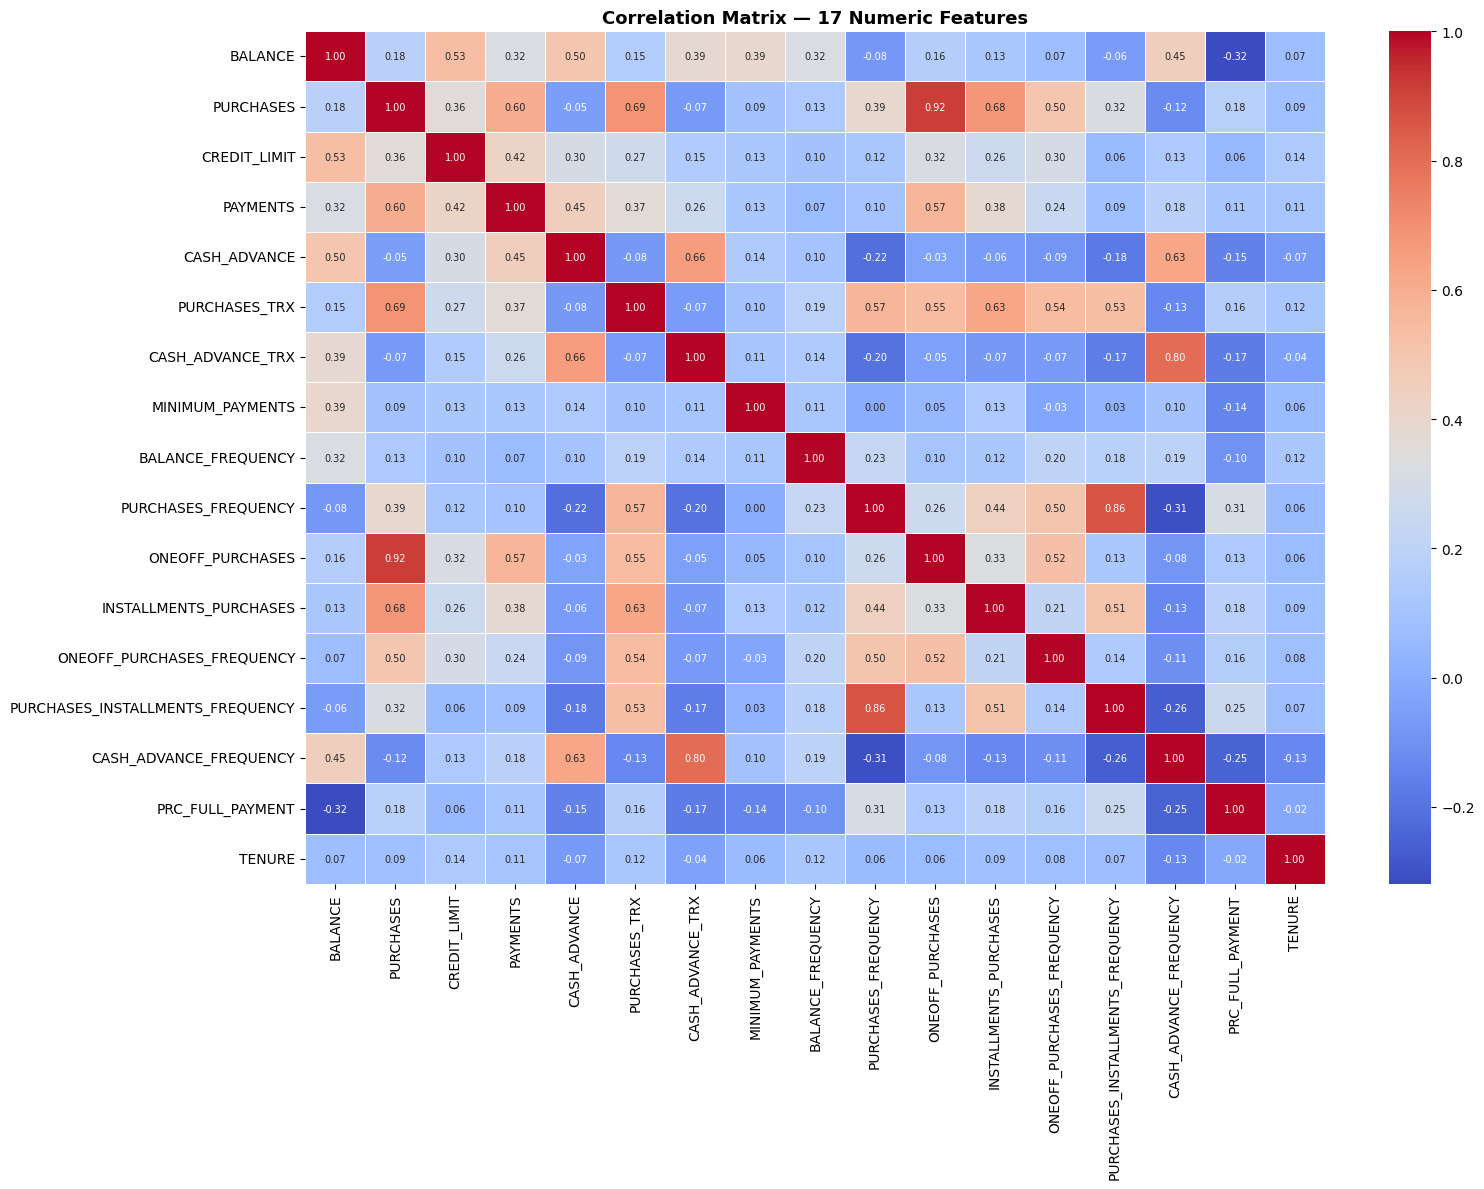

→ PURCHASES tương quan mạnh với ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, PURCHASES_TRX
→ CASH_ADVANCE tương quan với CASH_ADVANCE_TRX và CASH_ADVANCE_FREQUENCY
→ BALANCE tương quan với CREDIT_LIMIT và PAYMENTS → các biến tài chính liên kết chặt chẽ


In [158]:
# =============================================
# Ma trận tương quan (Correlation Matrix) - 17 columns gốc
# =============================================
plt.figure(figsize=(16, 12))
corr_matrix = df[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS',
                  'CASH_ADVANCE', 'PURCHASES_TRX', 'CASH_ADVANCE_TRX',
                  'MINIMUM_PAYMENTS', 'BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY',
                  'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
                  'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
                  'CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT', 'TENURE']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, annot_kws={'fontsize': 7})
plt.title('Correlation Matrix — 17 Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("→ PURCHASES tương quan mạnh với ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, PURCHASES_TRX")
print("→ CASH_ADVANCE tương quan với CASH_ADVANCE_TRX và CASH_ADVANCE_FREQUENCY")
print("→ BALANCE tương quan với CREDIT_LIMIT và PAYMENTS → các biến tài chính liên kết chặt chẽ")

/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


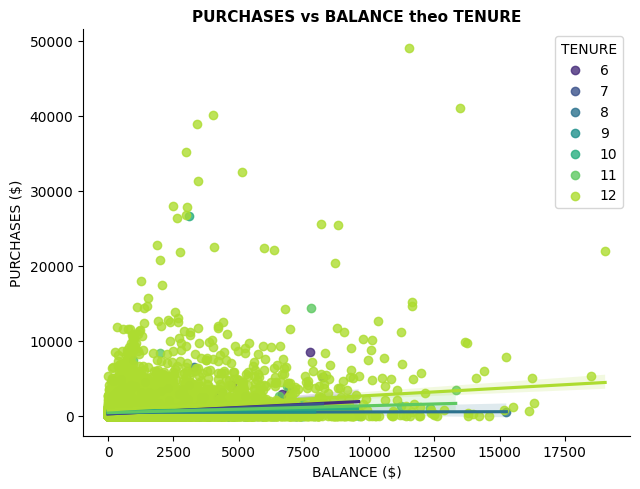

/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


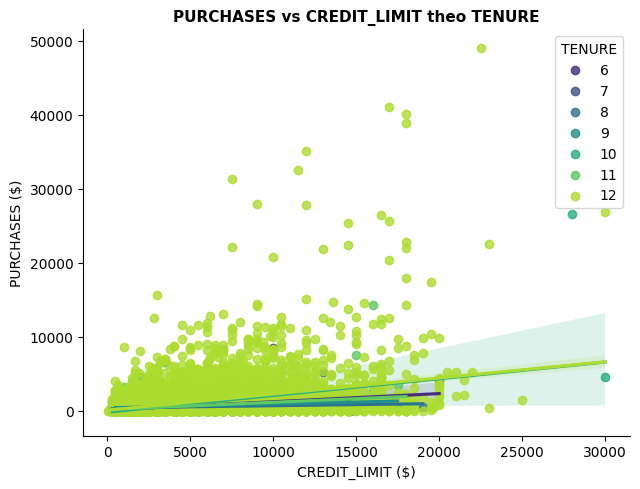

/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


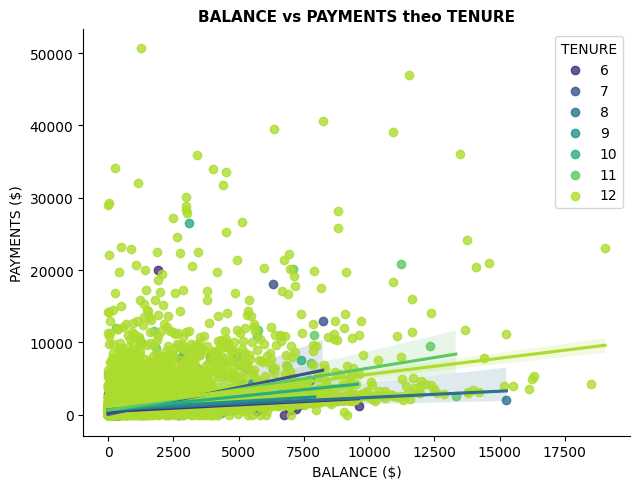

→ PURCHASES tỷ lệ thuận với BALANCE ở mọi TENURE (tương quan mạnh)
→ CREDIT_LIMIT càng cao → PURCHASES càng cao (khách dùng nhiều hơn)
→ PAYMENTS tăng theo BALANCE → khách có trách nhiệm tài chính


In [159]:
# =============================================
# LMplot: relationships giữa các biến numeric theo TENURE
# =============================================

# PURCHASES vs BALANCE theo TENURE
g1 = sns.lmplot(x='BALANCE', y='PURCHASES', data=df,
                 hue='TENURE', palette='viridis',
                 height=5, aspect=1.3, legend_out=False)
g1.set_axis_labels('BALANCE ($)', 'PURCHASES ($)')
plt.title('PURCHASES vs BALANCE theo TENURE', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# PURCHASES vs CREDIT_LIMIT theo TENURE
g2 = sns.lmplot(x='CREDIT_LIMIT', y='PURCHASES', data=df,
                 hue='TENURE', palette='viridis',
                 height=5, aspect=1.3, legend_out=False)
g2.set_axis_labels('CREDIT_LIMIT ($)', 'PURCHASES ($)')
plt.title('PURCHASES vs CREDIT_LIMIT theo TENURE', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# BALANCE vs PAYMENTS theo TENURE
g3 = sns.lmplot(x='BALANCE', y='PAYMENTS', data=df,
                 hue='TENURE', palette='viridis',
                 height=5, aspect=1.3, legend_out=False)
g3.set_axis_labels('BALANCE ($)', 'PAYMENTS ($)')
plt.title('BALANCE vs PAYMENTS theo TENURE', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("→ PURCHASES tỷ lệ thuận với BALANCE ở mọi TENURE (tương quan mạnh)")
print("→ CREDIT_LIMIT càng cao → PURCHASES càng cao (khách dùng nhiều hơn)")
print("→ PAYMENTS tăng theo BALANCE → khách có trách nhiệm tài chính")

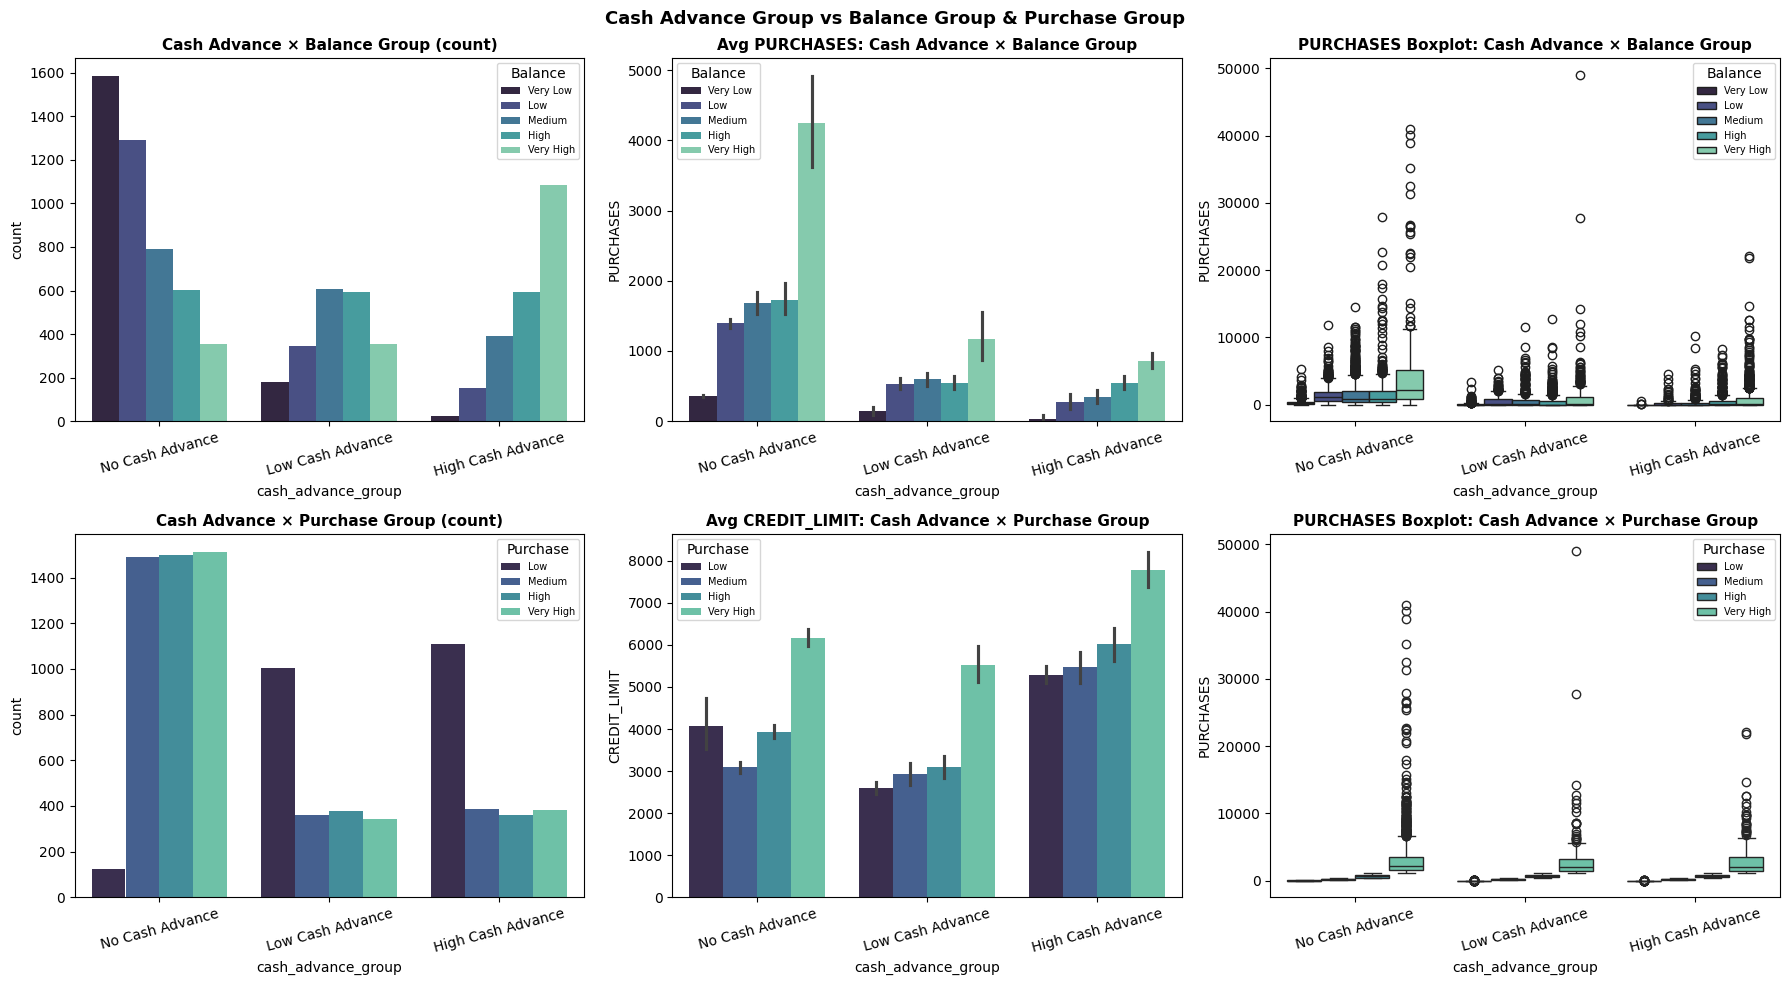

→ High Cash Advance + Very High Balance → nhóm rủi ro tài chính cao nhất
→ No Cash Advance có PURCHASES thấp hơn → khách lành mạnh tài chính
→ Purchase Group ảnh hưởng trực tiếp đến CREDIT_LIMIT


In [160]:
# =============================================
# CASH_ADVANCE theo PURCHASE_GROUP, BALANCE_GROUP, CREDIT_GROUP
# =============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

order_ca = ['No Cash Advance', 'Low Cash Advance', 'High Cash Advance']
order_balance = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
order_purchase = ['Low', 'Medium', 'High', 'Very High']

# Row 1: Cash Advance vs Balance Group
sns.countplot(x='cash_advance_group', hue='balance_group', data=df_cat,
             ax=axes[0, 0], palette='mako', order=order_ca)
axes[0, 0].set_title('Cash Advance × Balance Group (count)', fontsize=11, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=15)
axes[0, 0].legend(title='Balance', fontsize=7)

sns.barplot(x='cash_advance_group', y='PURCHASES', hue='balance_group', data=df_cat,
            ax=axes[0, 1], palette='mako', order=order_ca)
axes[0, 1].set_title('Avg PURCHASES: Cash Advance × Balance Group', fontsize=11, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].legend(title='Balance', fontsize=7, loc='upper left')

sns.boxplot(x='cash_advance_group', y='PURCHASES', hue='balance_group', data=df_cat,
            ax=axes[0, 2], palette='mako', order=order_ca)
axes[0, 2].set_title('PURCHASES Boxplot: Cash Advance × Balance Group', fontsize=11, fontweight='bold')
axes[0, 2].tick_params(axis='x', rotation=15)
axes[0, 2].legend(title='Balance', fontsize=7, loc='upper right')

# Row 2: Cash Advance vs Purchase Group
sns.countplot(x='cash_advance_group', hue='purchase_group', data=df_cat,
             ax=axes[1, 0], palette='mako', order=order_ca)
axes[1, 0].set_title('Cash Advance × Purchase Group (count)', fontsize=11, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].legend(title='Purchase', fontsize=7)

sns.barplot(x='cash_advance_group', y='CREDIT_LIMIT', hue='purchase_group', data=df_cat,
            ax=axes[1, 1], palette='mako', order=order_ca)
axes[1, 1].set_title('Avg CREDIT_LIMIT: Cash Advance × Purchase Group', fontsize=11, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].legend(title='Purchase', fontsize=7, loc='upper left')

sns.boxplot(x='cash_advance_group', y='PURCHASES', hue='purchase_group', data=df_cat,
            ax=axes[1, 2], palette='mako', order=order_ca)
axes[1, 2].set_title('PURCHASES Boxplot: Cash Advance × Purchase Group', fontsize=11, fontweight='bold')
axes[1, 2].tick_params(axis='x', rotation=15)
axes[1, 2].legend(title='Purchase', fontsize=7, loc='upper right')

plt.suptitle('Cash Advance Group vs Balance Group & Purchase Group', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("→ High Cash Advance + Very High Balance → nhóm rủi ro tài chính cao nhất")
print("→ No Cash Advance có PURCHASES thấp hơn → khách lành mạnh tài chính")
print("→ Purchase Group ảnh hưởng trực tiếp đến CREDIT_LIMIT")

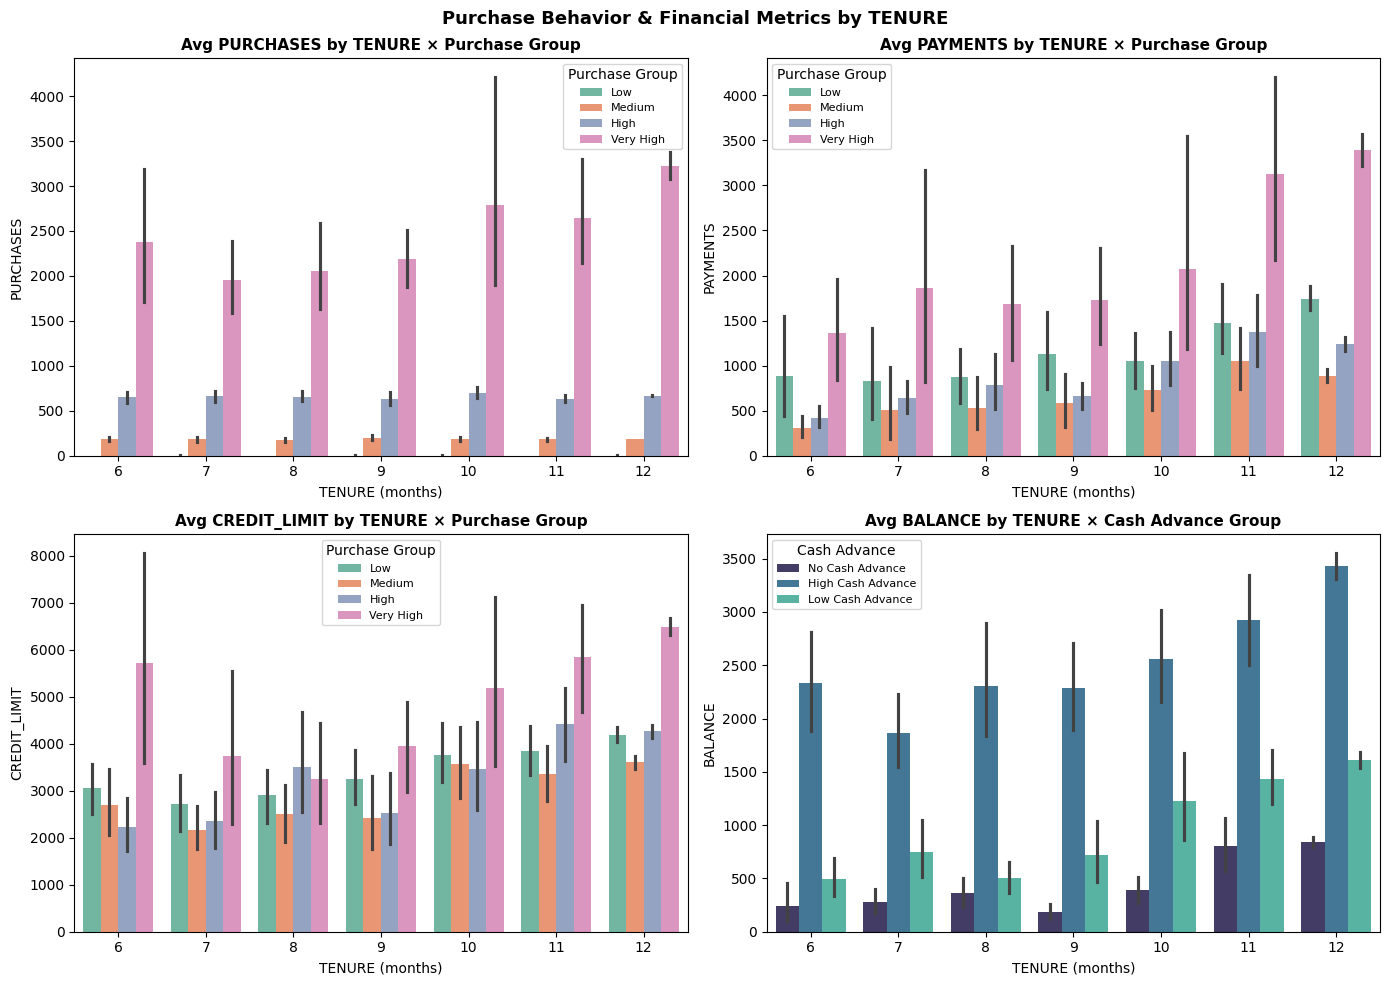

→ TENURE = 12: PURCHASES và PAYMENTS cao ở mọi Purchase Group, khách quen có chi tiêu ổn định
→ Khách TENURE thấp (6-9 tháng) có PURCHASES và CREDIT_LIMIT thấp hơn
→ High Cash Advance có BALANCE cao hơn ở mọi TENURE → rủi ro tài chính liên tục


In [161]:
# =============================================
# PURCHASE, CREDIT_LIMIT, PAYMENTS theo nhóm và TENURE
# =============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

order_tenure = sorted(df_cat['TENURE'].unique())
order_purchase = ['Low', 'Medium', 'High', 'Very High']
order_ca = ['No Cash Advance', 'Low Cash Advance', 'High Cash Advance']

# PURCHASES trung bình theo TENURE và Purchase Group
sns.barplot(x='TENURE', y='PURCHASES', hue='purchase_group', data=df_cat,
            ax=axes[0, 0], palette='Set2', order=order_tenure)
axes[0, 0].set_title('Avg PURCHASES by TENURE × Purchase Group', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('TENURE (months)')
axes[0, 0].legend(title='Purchase Group', fontsize=8)

# PAYMENTS trung bình theo TENURE và Purchase Group
sns.barplot(x='TENURE', y='PAYMENTS', hue='purchase_group', data=df_cat,
            ax=axes[0, 1], palette='Set2', order=order_tenure)
axes[0, 1].set_title('Avg PAYMENTS by TENURE × Purchase Group', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('TENURE (months)')
axes[0, 1].legend(title='Purchase Group', fontsize=8)

# CREDIT_LIMIT trung bình theo TENURE và Purchase Group
sns.barplot(x='TENURE', y='CREDIT_LIMIT', hue='purchase_group', data=df_cat,
            ax=axes[1, 0], palette='Set2', order=order_tenure)
axes[1, 0].set_title('Avg CREDIT_LIMIT by TENURE × Purchase Group', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('TENURE (months)')
axes[1, 0].legend(title='Purchase Group', fontsize=8)

# BALANCE trung bình theo TENURE và Cash Advance Group
sns.barplot(x='TENURE', y='BALANCE', hue='cash_advance_group', data=df_cat,
            ax=axes[1, 1], palette='mako', order=order_tenure)
axes[1, 1].set_title('Avg BALANCE by TENURE × Cash Advance Group', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('TENURE (months)')
axes[1, 1].legend(title='Cash Advance', fontsize=8)

plt.suptitle('Purchase Behavior & Financial Metrics by TENURE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("→ TENURE = 12: PURCHASES và PAYMENTS cao ở mọi Purchase Group, khách quen có chi tiêu ổn định")
print("→ Khách TENURE thấp (6-9 tháng) có PURCHASES và CREDIT_LIMIT thấp hơn")
print("→ High Cash Advance có BALANCE cao hơn ở mọi TENURE → rủi ro tài chính liên tục")

**Kết luận Data Visualization:**

- **Correlation:** PURCHASES tương quan chặt với ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, PURCHASES_TRX. CASH_ADVANCE liên quan mạnh với CASH_ADVANCE_TRX. BALANCE liên kết với CREDIT_LIMIT và PAYMENTS — nhóm biến tài chính có xu hướng đi cùng nhau.
- **LMplot:** PURCHASES tăng tuyến tính với BALANCE và CREDIT_LIMIT ở mọi TENURE. PAYMENTS tỷ lệ thuận với BALANCE → khách có dư nợ cao thường trả nhiều hơn.
- **Cash Advance vs Groups:** High Cash Advance + Very High Balance = nhóm rủi ro tài chính cao nhất → cần ưu tiên giám sát.
- **TENURE:** Khách quen (12 tháng) có PURCHASES, PAYMENTS, CREDIT_LIMIT ổn định và cao hơn khách mới (6-9 tháng).

> Insights hỗ trợ phân cụm: tập trung vào PURCHASES, BALANCE, CASH_ADVANCE, CREDIT_LIMIT, và TENURE là các biến có tương quan và phân tách rõ ràng giữa các nhóm khách.

# MODEL TRAINING

In [162]:
# =============================================
# FEATURE SELECTION & SCALING
# =============================================
from sklearn.preprocessing import StandardScaler

# Chọn 4 features cho classification (theo EDA: các biến phân tách tốt nhất)
features = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']
X = df[features].copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features đã chọn:", features)
print("Kích thước dữ liệu sau scaling:", X_scaled.shape)
print("\nScaled data sample:")
print(pd.DataFrame(X_scaled, columns=features).head())

Features đã chọn: ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']
Kích thước dữ liệu sau scaling: (8950, 4)

Scaled data sample:
    BALANCE  PURCHASES  CREDIT_LIMIT  PAYMENTS
0 -0.731989  -0.424900     -0.960433 -0.528979
1  0.786961  -0.469552      0.688639  0.818642
2  0.447135  -0.107668      0.826062 -0.383805
3  0.049099   0.232058      0.826062 -0.598688
4 -0.358775  -0.462063     -0.905464 -0.364368


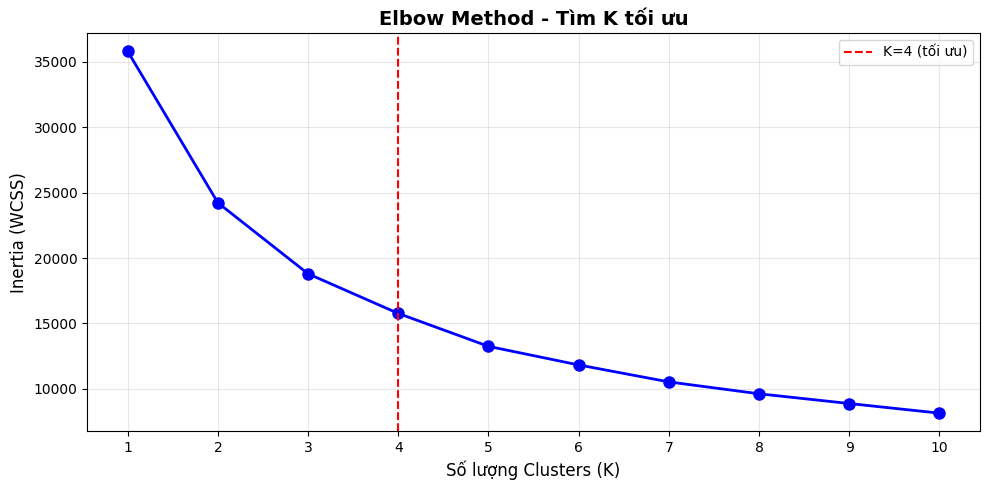

→ Chọn K=4 dựa trên Elbow Method


In [163]:
# =============================================
# K-MEANS CLUSTERING - Tìm K tối ưu bằng Elbow Method
# =============================================
from sklearn.cluster import KMeans

# Elbow Method
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Vẽ Elbow Plot
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Số lượng Clusters (K)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method - Tìm K tối ưu', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.axvline(x=4, color='r', linestyle='--', label='K=4 (tối ưu)')
plt.legend()
plt.tight_layout()
plt.show()

print("→ Chọn K=4 dựa trên Elbow Method")

K-Means Clustering - K=4

Số lượng khách hàng theo Cluster:
Cluster
0    5876
1    1040
2     130
3    1904
Name: count, dtype: int64


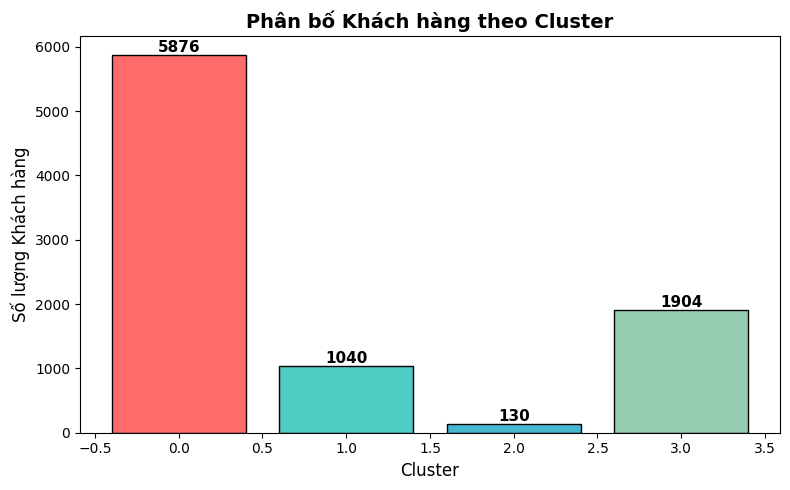


Trung bình các features theo Cluster:
         BALANCE  PURCHASES  CREDIT_LIMIT  PAYMENTS  Số khách
Cluster                                                      
0         835.87     464.35       2458.62    847.96      5876
1        5990.70    1058.20       9067.94   2760.39      1040
2        4752.77   11195.46      12514.23  17745.30       130
3        1177.67    1940.25       7731.61   2810.58      1904


In [164]:
# =============================================
# TRAIN K-MEANS VỚI K=4
# =============================================
# Train K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Thêm cluster labels vào dataframe gốc
print("K-Means Clustering - K=4")
print("=" * 50)
print(f"\nSố lượng khách hàng theo Cluster:")
print(df['Cluster'].value_counts().sort_index())

# Vẽ cluster distribution
plt.figure(figsize=(8, 5))
cluster_counts = df['Cluster'].value_counts().sort_index()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
plt.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Số lượng Khách hàng', fontsize=12)
plt.title('Phân bố Khách hàng theo Cluster', fontsize=14, fontweight='bold')
for i, v in enumerate(cluster_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Trung bình các features theo cluster
print("\nTrung bình các features theo Cluster:")
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
cluster_summary['Số khách'] = df['Cluster'].value_counts().sort_index()
print(cluster_summary)

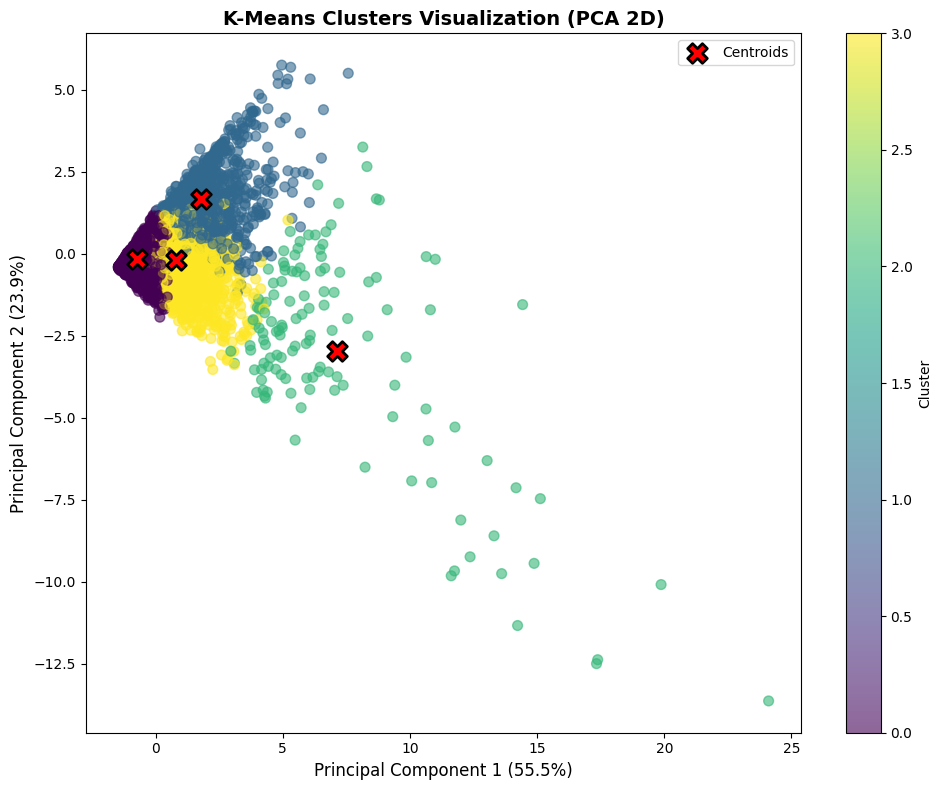

→ Tổng variance explained: 79.3%


In [165]:
# =============================================
# PCA VISUALIZATION - Trực quan hóa clusters
# =============================================
from sklearn.decomposition import PCA

# Giảm chiều về 2D để vẽ
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Vẽ clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], 
                      cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')

# Vẽ centroids (đã transform về PCA space)
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
           c='red', marker='X', s=200, edgecolors='black', linewidths=2,
           label='Centroids')

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title('K-Means Clusters Visualization (PCA 2D)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"→ Tổng variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

## CLASSIFICATION - KNN & Decision Tree

Train classifiers để dự đoán cluster cho khách hàng mới dựa trên 4 features đã chọn.

In [166]:
# =============================================
# TRAIN KNN & DECISION TREE CLASSIFIERS
# =============================================
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Chia train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, df['Cluster'], test_size=0.2, random_state=42, stratify=df['Cluster']
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# ----- K-NEAREST NEIGHBORS (KNN) -----
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)

print("\n" + "=" * 60)
print("K-NEAREST NEIGHBORS (KNN)")
print("=" * 60)
print(f"Accuracy: {knn_accuracy:.3f} ({knn_accuracy*100:.1f}%)")
print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

# ----- DECISION TREE -----
tree = DecisionTreeClassifier(random_state=42, max_depth=10)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_pred)

print("\n" + "=" * 60)
print("DECISION TREE")
print("=" * 60)
print(f"Accuracy: {tree_accuracy:.3f} ({tree_accuracy*100:.1f}%)")
print("\nClassification Report:")
print(classification_report(y_test, tree_pred))

# So sánh
print("\n" + "=" * 60)
print("SO SÁNH MÔ HÌNH")
print("=" * 60)
print(f"{'Model':<20} {'Accuracy':>10}")
print("-" * 30)
print(f"{'KNN (k=5)':<20} {knn_accuracy*100:>9.1f}%")
print(f"{'Decision Tree':<20} {tree_accuracy*100:>9.1f}%")

Training set: 7160 samples
Test set: 1790 samples

K-NEAREST NEIGHBORS (KNN)
Accuracy: 0.983 (98.3%)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1175
           1       0.96      0.97      0.97       208
           2       1.00      0.96      0.98        26
           3       0.97      0.96      0.96       381

    accuracy                           0.98      1790
   macro avg       0.98      0.97      0.98      1790
weighted avg       0.98      0.98      0.98      1790


DECISION TREE
Accuracy: 0.979 (97.9%)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1175
           1       0.98      0.97      0.97       208
           2       1.00      0.88      0.94        26
           3       0.95      0.96      0.96       381

    accuracy                           0.98      1790
   macro avg       0.98      0.95      0.96      17

RANDOM FOREST
Accuracy: 0.984 (98.4%)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1175
           1       0.99      0.97      0.98       208
           2       1.00      0.92      0.96        26
           3       0.95      0.98      0.96       381

    accuracy                           0.98      1790
   macro avg       0.98      0.96      0.97      1790
weighted avg       0.98      0.98      0.98      1790


FEATURE IMPORTANCE (Random Forest)
        Feature  Importance
2  CREDIT_LIMIT    0.464729
0       BALANCE    0.279399
3      PAYMENTS    0.142201
1     PURCHASES    0.113671


/tmp/ipykernel_56027/3209102448.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


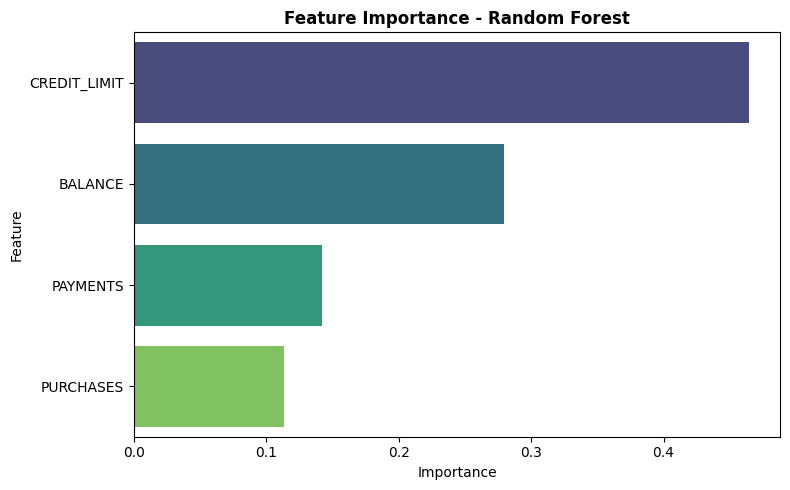

In [167]:
# =============================================
# TRAIN RANDOM FOREST CLASSIFIER
# =============================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ----- RANDOM FOREST -----
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)
print(f"Accuracy: {rf_accuracy:.3f} ({rf_accuracy*100:.1f}%)")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Feature Importance
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE (Random Forest)")
print("=" * 60)
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance)

# Vẽ feature importance
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance - Random Forest', fontsize=12, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


SO SÁNH TẤT CẢ MODELS
Model                       Accuracy
-----------------------------------
KNN (k=5)                      98.3%
Decision Tree                  97.9%
Random Forest                  98.4%


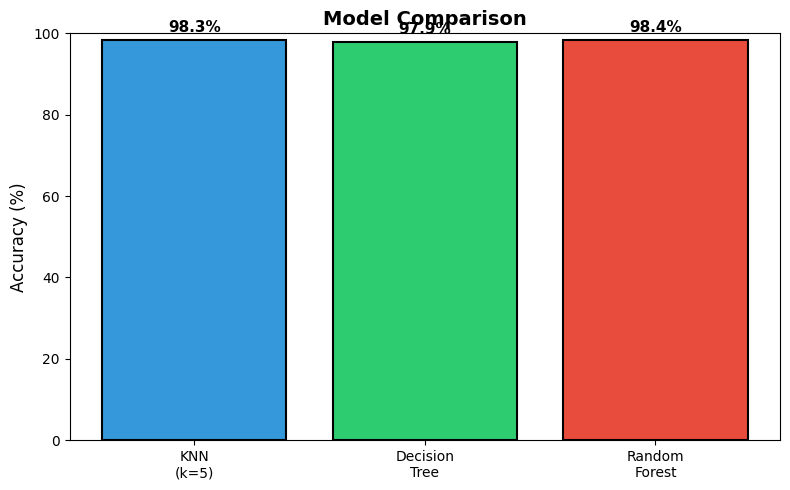

In [168]:
# =============================================
# SO SÁNH TẤT CẢ MODELS
# =============================================
print("\n" + "=" * 60)
print("SO SÁNH TẤT CẢ MODELS")
print("=" * 60)
print(f"{'Model':<25} {'Accuracy':>10}")
print("-" * 35)
print(f"{'KNN (k=5)':<25} {knn_accuracy*100:>9.1f}%")
print(f"{'Decision Tree':<25} {tree_accuracy*100:>9.1f}%")
print(f"{'Random Forest':<25} {rf_accuracy*100:>9.1f}%")

# Vẽ so sánh
models = ['KNN\n(k=5)', 'Decision\nTree', 'Random\nForest']
accuracies = [knn_accuracy*100, tree_accuracy*100, rf_accuracy*100]
colors = ['#3498db', '#2ecc71', '#e74c3c']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [174]:
# =============================================
# SAVE ALL MODELS
# =============================================
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(kmeans, 'models/kmeans.pkl')
joblib.dump(knn, 'models/knn.pkl')
joblib.dump(tree, 'models/tree.pkl')
joblib.dump(rf, 'models/rf.pkl')  # Random Forest
joblib.dump(scaler, 'models/scaler.pkl')

print("=" * 60)
print("ĐÃ LƯU TẤT CẢ MODELS THÀNH CÔNG!")
print("=" * 60)
print("\nFiles đã lưu:")
print("  - models/kmeans.pkl    (K-Means Clustering)")
print("  - models/knn.pkl       (K-Nearest Neighbors)")
print("  - models/tree.pkl      (Decision Tree)")
print("  - models/rf.pkl       (Random Forest)")
print("  - models/scaler.pkl   (StandardScaler)")

ĐÃ LƯU TẤT CẢ MODELS THÀNH CÔNG!

Files đã lưu:
  - models/kmeans.pkl    (K-Means Clustering)
  - models/knn.pkl       (K-Nearest Neighbors)
  - models/tree.pkl      (Decision Tree)
  - models/rf.pkl       (Random Forest)
  - models/scaler.pkl   (StandardScaler)


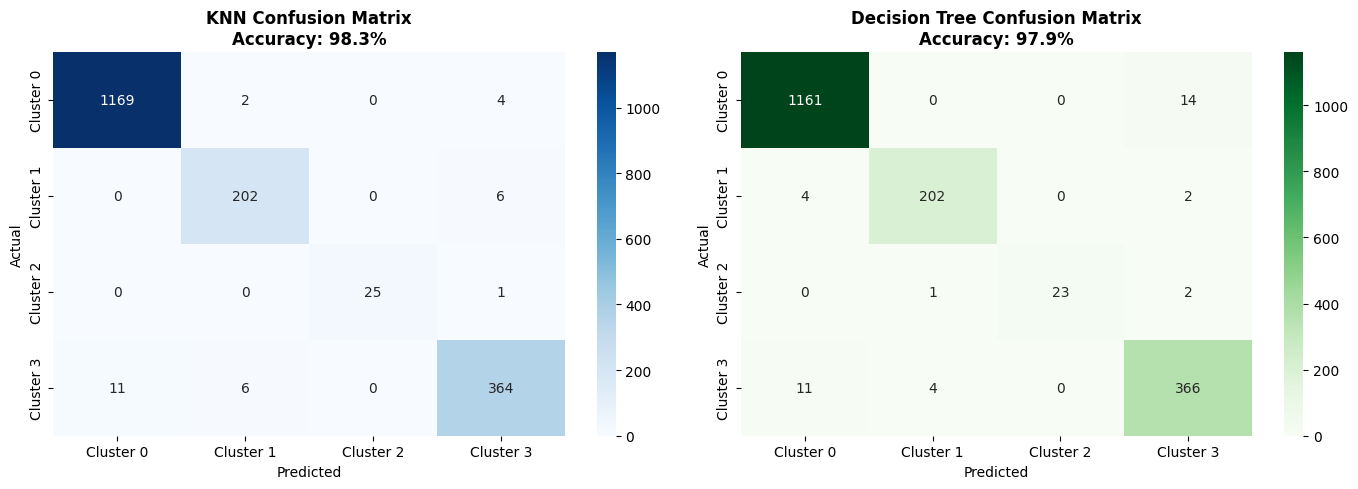

In [170]:
# =============================================
# CONFUSION MATRIX VISUALIZATION
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KNN Confusion Matrix
cm_knn = confusion_matrix(y_test, knn_pred)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'],
            yticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
axes[0].set_title(f'KNN Confusion Matrix\nAccuracy: {knn_accuracy*100:.1f}%', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree Confusion Matrix
cm_tree = confusion_matrix(y_test, tree_pred)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'],
            yticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
axes[1].set_title(f'Decision Tree Confusion Matrix\nAccuracy: {tree_accuracy*100:.1f}%', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [171]:
# =============================================
# SAVE MODELS
# =============================================
import joblib
import os

# Tạo folder models nếu chưa có
os.makedirs('models', exist_ok=True)

# Save models
joblib.dump(kmeans, 'models/kmeans.pkl')
joblib.dump(knn, 'models/knn.pkl')
joblib.dump(tree, 'models/tree.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Đã lưu models thành công!")
print("\nFiles đã lưu:")
print("  - models/kmeans.pkl")
print("  - models/knn.pkl")
print("  - models/tree.pkl")
print("  - models/scaler.pkl")

Đã lưu models thành công!

Files đã lưu:
  - models/kmeans.pkl
  - models/knn.pkl
  - models/tree.pkl
  - models/scaler.pkl


In [172]:
# =============================================
# PREDICTION EXAMPLE - Dự đoán cluster cho khách hàng mới
# =============================================

cluster_names = {
    0: "High Value Customers (Khách hàng giá trị cao)",
    1: "Low Activity Customers (Khách hàng ít hoạt động)",
    2: "Cash Advance Users (Khách hàng rút tiền mặt)",
    3: "Potential Premium (Khách hàng Premium tiềm năng)"
}

# Load models (để test)
knn_model = joblib.load('models/knn.pkl')
tree_model = joblib.load('models/tree.pkl')
scaler_model = joblib.load('models/scaler.pkl')

# Ví dụ khách hàng mới: BALANCE, PURCHASES, CREDIT_LIMIT, PAYMENTS
new_customer = np.array([[1000, 500, 3000, 1000]])

# Scale dữ liệu mới
new_customer_scaled = scaler_model.transform(new_customer)

# Dự đoán
knn_result = knn_model.predict(new_customer_scaled)[0]
tree_result = tree_model.predict(new_customer_scaled)[0]

print("=" * 60)
print("DỰ ĐOÁN CLUSTER CHO KHÁCH HÀNG MỚI")
print("=" * 60)
print(f"\nThông tin khách hàng:")
print(f"  BALANCE: ${new_customer[0][0]:.2f}")
print(f"  PURCHASES: ${new_customer[0][1]:.2f}")
print(f"  CREDIT_LIMIT: ${new_customer[0][2]:.2f}")
print(f"  PAYMENTS: ${new_customer[0][3]:.2f}")
print(f"\nKNN Prediction: Cluster {knn_result} - {cluster_names[knn_result]}")
print(f"Decision Tree Prediction: Cluster {tree_result} - {cluster_names[tree_result]}")

DỰ ĐOÁN CLUSTER CHO KHÁCH HÀNG MỚI

Thông tin khách hàng:
  BALANCE: $1000.00
  PURCHASES: $500.00
  CREDIT_LIMIT: $3000.00
  PAYMENTS: $1000.00

KNN Prediction: Cluster 0 - High Value Customers (Khách hàng giá trị cao)
Decision Tree Prediction: Cluster 0 - High Value Customers (Khách hàng giá trị cao)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [173]:
# =============================================
# PREDICTION EXAMPLE - All Models
# =============================================
cluster_names = {
    0: "High Value Customers",
    1: "Low Activity Customers",
    2: "Cash Advance Users",
    3: "Potential Premium"
}

# Load models
knn_model = joblib.load('models/knn.pkl')
tree_model = joblib.load('models/tree.pkl')
rf_model = joblib.load('models/rf.pkl')
scaler_model = joblib.load('models/scaler.pkl')

# Test với 2 ví dụ khách hàng
test_customers = np.array([
    [1000, 500, 3000, 1000],   # Customer 1
    [5000, 8000, 15000, 7000]  # Customer 2
])
test_scaled = scaler_model.transform(test_customers)

print("=" * 70)
print("DỰ ĐOÁN CLUSTER CHO NHIỀU KHÁCH HÀNG")
print("=" * 70)

for i, customer in enumerate(test_customers):
    print(f"\n--- Khách hàng {i+1} ---")
    print(f"BALANCE: ${customer[0]:.2f}, PURCHASES: ${customer[1]:.2f}")
    print(f"CREDIT_LIMIT: ${customer[2]:.2f}, PAYMENTS: ${customer[3]:.2f}")
    print(f"\n{'Model':<15} {'Cluster':>8} {'Tên':<25}")
    print("-" * 50)
    for name, model in [('KNN', knn_model), ('Decision Tree', tree_model), ('Random Forest', rf_model)]:
        result = model.predict(test_scaled[i:i+1])[0]
        print(f"{name:<15} {result:>8} {cluster_names[result]:<25}")

DỰ ĐOÁN CLUSTER CHO NHIỀU KHÁCH HÀNG

--- Khách hàng 1 ---
BALANCE: $1000.00, PURCHASES: $500.00
CREDIT_LIMIT: $3000.00, PAYMENTS: $1000.00

Model            Cluster Tên                      
--------------------------------------------------
KNN                    0 High Value Customers     
Decision Tree          0 High Value Customers     
Random Forest          0 High Value Customers     

--- Khách hàng 2 ---
BALANCE: $5000.00, PURCHASES: $8000.00
CREDIT_LIMIT: $15000.00, PAYMENTS: $7000.00

Model            Cluster Tên                      
--------------------------------------------------
KNN                    2 Cash Advance Users       
Decision Tree          2 Cash Advance Users       
Random Forest          2 Cash Advance Users       


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
